In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pandas as pd
from numba import njit
from scipy import odr
from scipy.special import voigt_profile
from scipy.optimize import curve_fit
from scipy import stats as st
import time

os.chdir('F:/LANL/')
# os.chdir('/mnt/c/Users/gabeo/Desktop/analysis_temp/')
root = os.getcwd()

processedfolder = '/processed_data/'
vconstantsavename = root+processedfolder+'1_vparams_Pr'  ## MAKE SURE TARGET IS CORRECT !

search_arr = sorted(os.listdir(root + processedfolder))
print('Searhing in array (sorted): ', search_arr)
# print(search_arr[0])
folders_start = 'runs'+'12686-13279'
folders_end = 'runs'+'13564-13604'
# print(folders_start)
start_i = search_arr.index(folders_start)
end_i = search_arr.index(folders_end)
print('Indices in above array, starti-endi:', start_i,'-', end_i)
# print(end_i)
# print(len(search_arr[start_i:end_i+1]))

folderslist = []
if folders_start == folders_end:
    currfolder = search_arr[start_i]+'/'
    folderslist.append(currfolder)
else:
    for f in range(start_i, end_i+1):
#         print(f)
#         print(search_arr[f])
        currfolder = root+processedfolder+search_arr[f]
        currfolder = search_arr[f]+'/'
        print(currfolder)
        folderslist.append(currfolder)
#     runslist_D[f] = sorted(os.listdir(root+processedfolder+folders_start+'/asym_D'))
#     runslist_U[f] = sorted(os.listdir(root+processedfolder+folders_start+'/asym_U'))

numfolders = len(folderslist)
print(numfolders, 'folders, array of folders is: ', folderslist)

## change below to multiple folders?
runslist_D = []  ## array of runfolders, runs
runslist_U = []
for i in range(len(folderslist)):
    runslist_D.append(sorted(os.listdir(root+processedfolder+folderslist[i]+'/pulseadd_D')))
    runslist_U.append(sorted(os.listdir(root+processedfolder+folderslist[i]+'/pulseadd_U')))
# runslist_D = sorted(os.listdir(root+processedfolder+folders_start+'/ONOFF_D')) ## has to be changed to an array
# runslist_U = sorted(os.listdir(root+processedfolder+folders_start+'/ONOFF_U'))
# runslist_D =np.asarray(runslist_D)
# runslist_U =np.asarray(runslist_U)
print(len(runslist_D))
print(len(runslist_D[0]))
print(len(runslist_D[1]))
## now flatten list so that all runs are in one array ## not sure I will use this
flatrunslist_D = [run for folder in runslist_D for run in folder]
flatrunslist_D = np.asarray(flatrunslist_D)
flatrunslist_U = [run for folder in runslist_U for run in folder]
flatrunslist_U = np.asarray(flatrunslist_U)
print(len(flatrunslist_D))

numruns_tot_D = len(flatrunslist_D) ## U and D should be the same? ## should change to num pulses maybe
numruns_tot_U = len(flatrunslist_U) ## 
print(numruns_tot_D)
print(numruns_tot_U)


Searhing in array (sorted):  ['0_vparams_La.h5', '1_vparams_Pr.h5', 'La_sample', '_temp_xs.npy', 'quick', 'runs07862-08069', 'runs09919-10159', 'runs11121-11138', 'runs11139-11412', 'runs11413-11726', 'runs11727-12033', 'runs12034-12363', 'runs12364-12684', 'runs12686-13279', 'runs13280-13563', 'runs13564-13604', 'runs13605-13735', 'runs13736-13851', 'runs13852-14191', 'runs14192-14499', 'runs14500-15106', 'runs15114-15568', 'runs15569-16110', 'runs16135-16392', 'runs16453-16763', 'runs88888-99999', 's_vparams_La.h5', 'xs_cut.npy', 'xs_uncut.npy']
Indices in above array, starti-endi: 13 - 15
runs12686-13279/
runs13280-13563/
runs13564-13604/
3 folders, array of folders is:  ['runs12686-13279/', 'runs13280-13563/', 'runs13564-13604/']
3
283
124
448
448
448


In [2]:
plt.rcParams.update({
    'axes.titlesize': 'xx-large',
    'axes.labelsize': 'x-large',
    'xtick.labelsize': 'x-large',
    'ytick.labelsize': 'x-large',
    'xtick.minor.visible': 'True',
    'ytick.minor.visible': 'True',
    'axes.grid': 'True',
    'axes.grid.which': 'both',
    'grid.alpha': '0.70',
    'grid.linestyle': ':',
    'legend.fontsize': 'large',
    'figure.figsize': '10.0, 7.0',
    'backend': 'Qt5agg',
    'interactive': 'True',
    'figure.autolayout': 'True',
})
# %matplotlib qt
print('updated rcparam')

updated rcparam


In [3]:
%matplotlib inline

# Need to get num pulses!!! ending runs dont have as many pulses !!

In [4]:
## load in the x array. Also helps in determining sizes
channels_all = []
folderpath = root+processedfolder+folderslist[0]
with h5py.File(folderpath+'/pulseadd_D/'+runslist_D[0][0], 'r') as f: ## new arr_sizer
    channels_D = list(f.keys())
    channels_all.append(channels_D[:-2])
    numchannels = len(channels_D)-1
    dataset = f[channels_D[-1]]   ## this is the xs dataset
    xs = np.array(dataset)*1e-6 ## now in ms
    numpoints = len(xs)
    f.close()
    
with h5py.File(folderpath+'/pulseadd_U/'+runslist_U[0][0], 'r') as f: ## new arr_sizer
    channels_U = list(f.keys())
    channels_all=np.append(channels_all, channels_U[:-1])
#     channels_all.append(channels[:-1])
    numchannels = len(channels_U)-1
    dataset = f[channels_U[-1]]   ## this is the xs dataset
    xs = np.array(dataset)*1e-6 ## now in ms
    numpoints = len(xs)
    f.close()
# print(channels_all)
# channels_all = np.asarray(channels_all, dtype=object)
# print(channels_all)
# channels_all = channels_all.flatten()
print(numruns_tot_D,numchannels,numpoints)
# print(data.shape)
# print(data[seq][0][0])
print(channels_all[:])
print(channels_all[-1])
print(len(xs))
print(channels_D)
print(channels_U)

print(channels_all)

# print(channels_all.flatten())
# print(data)

448 13 8992
['ch_00' 'ch_01' 'ch_02' 'ch_03' 'ch_04' 'ch_05' 'ch_06' 'ch_07' 'ch_08'
 'ch_09' 'ch_10' 'ch_11' 'ch_12' 'ch_13' 'ch_14' 'ch_15' 'ch_16' 'ch_17'
 'ch_18' 'ch_19' 'ch_20' 'ch_21' 'ch_22' 'ch_23' 'ch_24']
ch_24
8992
['ch_00', 'ch_01', 'ch_02', 'ch_03', 'ch_04', 'ch_05', 'ch_06', 'ch_07', 'ch_08', 'ch_09', 'ch_10', 'ch_11', 'ch_24', 'xs ']
['ch_12', 'ch_13', 'ch_14', 'ch_15', 'ch_16', 'ch_17', 'ch_18', 'ch_19', 'ch_20', 'ch_21', 'ch_22', 'ch_23', 'ch_24', 'xs ']
['ch_00' 'ch_01' 'ch_02' 'ch_03' 'ch_04' 'ch_05' 'ch_06' 'ch_07' 'ch_08'
 'ch_09' 'ch_10' 'ch_11' 'ch_12' 'ch_13' 'ch_14' 'ch_15' 'ch_16' 'ch_17'
 'ch_18' 'ch_19' 'ch_20' 'ch_21' 'ch_22' 'ch_23' 'ch_24']


In [5]:
print(channels_all[13])
# print(runslist_D)
print(len(folderslist))
print(len(runslist_D[1]))
print(runslist_D[1][0])

ch_13
3
124
13292_pulseadd_D.h5


In [6]:
def loadrun_pulseadd(run, processedpath): ## not sure if this is the fastest way, or passing a list of runs...
    runname = processedpath+run
    with h5py.File(runname, 'r') as f:
        channels = list(f.keys())
        numchannels = len(channels)-1
        arrsizer = f[channels[-1]] ## gets the xs array
        arrsizer = np.asarray(arrsizer)
        numpoints = len(arrsizer)
        rundat = np.zeros((numchannels,numpoints),dtype = np.float64)
#             print(str(np.char.zfill(str(chan_enab[i]),2)))
#             dataset = f['ch '+str(np.char.zfill(str(chan_enab[i]), 2))]
        for i in range(0,numchannels):
            dataset = f[channels[i]+'/added_pulses/'+channels[i]][:]  ##change this to match channels[i]
            chdata = np.array(dataset)
            rundat[i] = rundat[i]+chdata
        f.close()
    return rundat

In [7]:
start=time.time()
# all_D = [] ## in this case cannot be np array because it is not same size arrays ## will be run, channel, numpoints
# all_D = np.zeros((numruns_tot_D, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
# all_U = np.zeros((numruns_tot_U, numchannels,numpoints),dtype = np.float64) ## run, channel, numpoints ## works if flatten the folders
all_D = []
all_U = []

for f in range(0,len(folderslist)):
    fpath = root+processedfolder+folderslist[f]
    for r in range(0, len(runslist_D[f])):
#         print(runslist_D[f][r])
#         all_D.append(loadrun_pulseadd(runslist_D[f][r], fpath+'/pulseadd_D/'))
#         print(r)
#         all_D[r] = loadrun_pulseadd(runslist_D[f][r], fpath+'/pulseadd_D/')
#         all_U[r] = loadrun_pulseadd(runslist_U[f][r], fpath+'/pulseadd_U/')
        all_D.append(loadrun_pulseadd(runslist_D[f][r], fpath+'/pulseadd_D/'))
        all_U.append(loadrun_pulseadd(runslist_U[f][r], fpath+'/pulseadd_U/'))
#         print(all_D[r])
    print(fpath+' done')

all_D = np.asarray(all_D)
all_U = np.asarray(all_U)
## don't do below yet, rest of program assumes run, ch
# all_D = all_D.transpose(1, 0, 2) ## change from [run, ch, numsamples] to [ch, run, numsamples] !!!!
# all_U = all_U.transpose(1, 0, 2)
    
end=time.time()
print('loaded files time: ', end-start)

F:\LANL/processed_data/runs12686-13279/ done
F:\LANL/processed_data/runs13280-13563/ done
F:\LANL/processed_data/runs13564-13604/ done
loaded files time:  48.93128442764282


In [8]:
def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))

                         all_D: 399.5 MiB
                         all_U: 399.5 MiB
                            xs: 70.4 KiB
                flatrunslist_D: 33.4 KiB
                flatrunslist_U: 33.4 KiB
                           _i1:  2.7 KiB
                            _i:  1.4 KiB
                           _i7:  1.4 KiB
                           _i4:  1.3 KiB
                           _ii:  889.0 B


In [9]:
def g_flash_off(ys, search_region=(1800,2200), threshold_frac=0.3):
    # print(ys)
    seg = ys[search_region[0]:search_region[1]]
    # print(seg)
    n = seg.size
    baseline = np.median(seg[:max(1, n//10)])
    peak = np.max(seg)
    thr = baseline + threshold_frac*(peak - baseline) ## sets threshold dynamically based on gamma flash amp.
    idxs = np.where(seg > thr)[0]
    if idxs.size == 0: ## if no gamma flash is detected, then put a special flag
        return -1
    for ii in idxs:
        if ii+1 < n and seg[ii+1] >= seg[ii]:
            return search_region[0] + ii
    return search_region[0] + idxs[0]

def align_spec(ys_ch, gflash_bin, fill_unchanged=True):
    """Return ys rolled by -(gflash_bin - median_flash) per run."""
    detected = gflash_bin >= 0  ## checks if a gflash was detected, see g_flash_off f(x)
    if np.any(detected):
        median_flash = int(np.median(gflash_bin[detected]))
    else:
        median_flash = 0
    offsets = np.zeros(len(gflash_bin), dtype=int)
    offsets[detected] = gflash_bin[detected] - median_flash
    ys_roll = np.empty_like(ys_ch)
    for r in range(len(gflash_bin)):
        if (gflash_bin[r] < 0) and fill_unchanged:
            ys_roll[r] = ys_ch[r].copy()
        else:
            ys_roll[r] = np.roll(ys_ch[r], -offsets[r])
    return ys_roll, offsets

In [10]:
if all_D.shape[0] != all_U.shape[0]:
    emessage = ('Downstream and Upstream do not have equal # runs!')
    raise Exception(emessage)

offs_D = []
offs_U = []
for ch in range(0, all_D.shape[1]): # for every channel
    offs_ch_D = []
    offs_ch_U = []
    for r in range(0, all_D.shape[0]): # for every run
        bin_i_D = g_flash_off(all_D[r,ch])
        bin_i_U = g_flash_off(all_U[r,ch])
        offs_ch_D.append(bin_i_D)
        offs_ch_U.append(bin_i_U)
    offs_D.append(offs_ch_D)
    offs_U.append(offs_ch_U)
offs_D, offs_U = np.array(offs_D), np.array(offs_U)

print((offs_D.shape), (offs_U.shape))
print(offs_D[1,10:20], offs_U[1,10:20])

rolled_D = []
rolled_U = []
for ch in range(0, all_D.shape[1]): # for every channel
    rolled_ch_D, _ = align_spec(all_D[:,ch], offs_D[ch])
    rolled_ch_U, _ = align_spec(all_U[:,ch], offs_U[ch])
    rolled_D.append(rolled_ch_D)
    rolled_U.append(rolled_ch_U)
    
rolled_D, rolled_U = np.array(rolled_D).transpose(1, 0, 2), np.array(rolled_U).transpose(1, 0, 2) ## goes back to [run, ch, points] for consistency

print((rolled_D.shape), (rolled_U.shape))


(13, 448) (13, 448)
[1994 1994 1994 1994 1993 1994 1993 1993 1994 1994] [1994 1994 1994 1994 1993 1994 1993 1993 1994 1994]
(448, 13, 8992) (448, 13, 8992)


In [11]:
## redefine all_D to shifted ones. keeps names consistent afterward.

all_D, all_U = rolled_D, rolled_U

In [12]:
# ## add up all pulses to look at a nice spectra
# start = time.time()

# # @njit
# # def run_add(bef_res_reg, aft_res_reg, ys, order): ## before/after resonance region [start:end] respectively, ys[ch] to fit
# #     binstot = aft_res_reg[1]-bef_res_reg[0]  ## total number of bins in whole region
# #     x1 = np.arange(bef_res_reg[0], bef_res_reg[1],1)
# #     x2 = np.arange(aft_res_reg[0], aft_res_reg[1],1)
# #     x = np.append(x1,x2)
# #     fullx = np.arange(bef_res_reg[0], aft_res_reg[1],1) ## an array of every x bin in entire region
# #     ys_bgsub = []
# #     fitdata1 = ys[bef_res_reg[0]: bef_res_reg[1]]
# #     fitdata2 = ys[aft_res_reg[0]: aft_res_reg[1]]
# #     datasplice = np.append(fitdata1, fitdata2)
# #     y = datasplice
    
# #     coeffs, errs = polyN_fit_errors(x, y,order) # use new fit functions 
# # #     print("Fitted Coefficients:", coeffs)
# # #     print('Uncertainty ', errs)
# #     y_fit = polyN_predict(x, coeffs) ## run the function with the coeff you just found
# #     fullpoly_y2 = polyN_predict(fullx, coeffs)

# #     bgsubtracted = ys[bef_res_reg[0]:aft_res_reg[1]] - fullpoly_y2  ## subtracts RealData-BackgroundFit
# #     ys_bgsub.append(bgsubtracted)
# #     return ys_bgsub[0] ## the array notation is left over from before...

# ## background subtraction currently only for NaI detectors
# num_fittingchs = numchannels-1  ## removes the Li detector, assumes it is there
# print(num_fittingchs)
# spectra_D = np.zeros((numchannels,numpoints), dtype = np.float64) ## channels, range of bg_ subtraction
# spectra_U = np.zeros((numchannels,numpoints), dtype = np.float64) ## channels, range of bg_ subtraction

# addtimes=0
# for r in range(0, len(all_D)): ## for every run
# #     print(r)
#     start = time.time()
#     if r == 0 or r==100 or r==200 or r==300 or r==400 or r==500 or r==len(all_D)-1:
#         print(rf'run {r}, '+'100 runs took '+str(addtimes))
#         addtimes=0
#     for ch in range(0, numchannels): ## and every channel
# #         if channels_D[ch] == 'ch_24':
# #             emessage = ('bg_ fit does not work for 6Li yet')
# #             print(emessage)
# #             logger.error('run '+run_num + emessage)
# #             raise Exception(emessage)
# #         print(r, ch)
# #         print(channels[ch])
# #         print(len(bgsub_D[r][ch]))
# #         print(len(all_D[r][ch]))
#         spectra_D[ch] = spectra_D[ch]+all_D[r][ch]
#         spectra_U[ch] = spectra_U[ch]+all_U[r][ch]
#     end = time.time()
#     addtimes = addtimes+(end-start)
# #     times3.append(end-start)
# #     print('run took '+str(end-start))

In [13]:
## makes a total spectra out of all runs. Second version w function.
def spectra_maker(allarray_DU):  ## make sure array is Downstream _D then Upstream _U!!!
    addtimes=0
    if len(allarray_DU[0])!=len(allarray_DU[1]):
        emessage = 'Error: different num of down and up runs'
        raise Exception(emessage)
    allDarr = allarray_DU[0]
    allUarr = allarray_DU[1]
    # print(allDarr.shape)
    spectra_D = np.zeros((numchannels,numpoints), dtype = np.float64) 
    spectra_U = np.zeros((numchannels,numpoints), dtype = np.float64)
    print(f'number of runs: {len(allDarr)}')
    printruns = np.linspace(len(allDarr)//5, len(allDarr), 5, dtype=int)
    for r in range(0, len(allDarr)): ## for every run
        # print(r)
        start = time.time()
        if r ==printruns[0]  or r==printruns[1] or r==printruns[2] or r==printruns[3] or r==printruns[4]:
            print(rf'to run {r} took another {addtimes}')
            addtimes=0
        for ch in range(0, numchannels): ## and every channel
    #         if channels_D[ch] == 'ch_24':
    #             emessage = ('bg_ fit does not work for 6Li yet')
    #             print(emessage)
    #             logger.error('run '+run_num + emessage)
    #             raise Exception(emessage)
            # print(r, ch)
    #         print(channels[ch])
    #         print(len(bgsub_D[r][ch]))
    #         print(len(all_D[r][ch]))
            spectra_D[ch] = spectra_D[ch]+allDarr[r][ch]
            spectra_U[ch] = spectra_U[ch]+allUarr[r][ch]
        end = time.time()
        addtimes = addtimes+(end-start)
    return spectra_D, spectra_U

In [14]:
## add up all pulses to look at a nice spectra
%matplotlib inline
start = time.time()

if numchannels != 13:
    emessage = 'numchannels does not have 6Li'
    raise Exception(emessage)
num_fittingchs = numchannels-1  ## removes the Li detector, assumes it is there
print(num_fittingchs)

print('Pr')
spectra_D, spectra_U = spectra_maker([all_D, all_U])
spectra = np.vstack((spectra_D[:-1], spectra_U)) ## combine up- and down-stream
print(spectra.shape, '\n')
# plt.plot(spectra[1])

12
Pr
number of runs: 448
to run 89 took another 0.026905298233032227
to run 178 took another 0.030649662017822266
to run 268 took another 0.03402829170227051
to run 358 took another 0.033220767974853516
(25, 8992) 



In [15]:
m_n = 1.6749286*10**(-27)
# L = 0
J_to_eV = 6.24151*10**18
eV_to_J = 1.602176565*10**-19

def tof_to_eV(xtof, FPlength, t_off):
    m_n = 1.6749286*10**(-27)
    delay = t_off
    x_eV_out = 0.5*m_n*((FPlength/((xtof+delay)/1000)))**2*J_to_eV  ## tof in ms
    return x_eV_out
def eV_to_tof(xeV, FPlength, t_off):
    m_n = 1.6749286*10**(-27)
    delay = t_off
    x_tof_out = delay + 1000*FPlength*np.sqrt(m_n/(2*xeV*eV_to_J))  ## tof in ms
    return x_tof_out

h = 6.62607015e-34  # J*s
m_to_A = 1e10       # meters to Angstrom

def tof_to_lambda(xtof, FPlength, t_off):
    E_eV = tof_to_eV(xtof, FPlength, t_off)
    E_J = E_eV * eV_to_J 
    p = np.sqrt(2 * m_n * E_J)  # momentum
    lam = h / p * m_to_A # wavelength
    return lam  ## output in Angstrom

In [16]:
print(tof_to_eV(1.01,23.5,0))
print(eV_to_tof(4.22, 23.5,0))

2.8297557452780215
0.827064920061242


1996


C:\Users\gabeo\AppData\Local\Temp\ipykernel_24700\293523990.py:9: RuntimeWarning: divide by zero encountered in divide
  x_eV_out = 0.5*m_n*((FPlength/((xtof+delay)/1000)))**2*J_to_eV  ## tof in ms


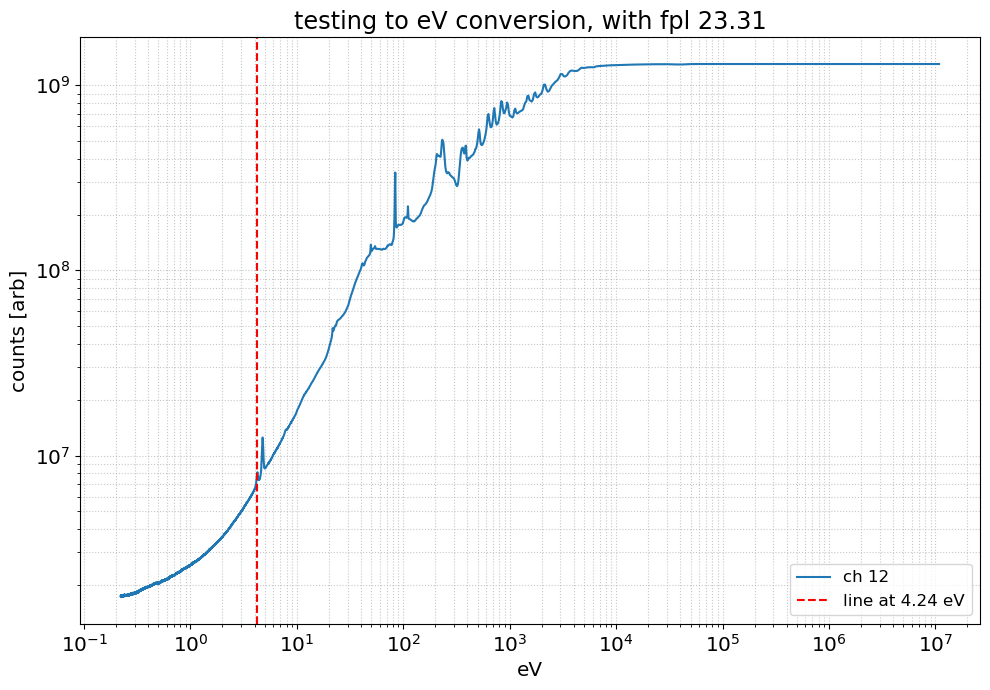

In [17]:
# fpl = 23.497
fpl = 23.31
zeropoint = np.where(xs>=0)[0][0]
daq_delay = 0
print(zeropoint)
xpos = xs[zeropoint:]
x_eV = tof_to_eV(xpos, fpl, daq_delay)
spectra_pos = spectra[:,zeropoint:]

plt.loglog(x_eV, spectra_pos[ch], label=f'ch {ch}')
plt.title(f'testing to eV conversion, with fpl {fpl}')
plt.ylabel('counts [arb]',fontsize = 'x-large')
plt.xlabel('eV',fontsize = 'x-large')
lineeV = 4.24
plt.axvline(x = lineeV,ls = '--', c = 'r', label=f'line at {lineeV} eV')
# plt.ylim(3000,14000)
# plt.xlim(1.5,3.0)
plt.legend()
plt.show()

## using pulseadd to find best values for voigt fits. Get fit values for every run (to get a distribution of x_loc, sig, gam

In [18]:
## try with chat gpt lol

In [19]:
@njit
def polyN_fit_errors(x, y, degree):
    """Fit y = a0*x^n + a1*x^(n-1) + ... + an using least squares and return errors.
Parameters:
        x : 1D array of inputs
        y : 1D array of outputs
        degree : int, degree of polynomial
Returns:
        coeffs : array of fitted coefficients [a0, a1, ..., an]
        stderr : array of standard errors (1-sigma) for each coefficient"""
    n = x.shape[0]
    A = np.empty((n, degree + 1))
    for i in range(n):
        xi = x[i]
        A[i, degree] = 1.0
        for j in range(degree - 1, -1, -1):
            A[i, j] = A[i, j + 1] * xi

    ATA = A.T @ A
    ATy = A.T @ y
    coeffs = np.linalg.solve(ATA, ATy)

    # Calculate residuals and variance
    y_fit = A @ coeffs
    residuals = y - y_fit
    dof = n - (degree + 1)
    residual_variance = np.sum(residuals**2) / dof

    # Covariance matrix and standard errors
    cov_matrix = np.linalg.inv(ATA) * residual_variance
    stderr = np.sqrt(np.diag(cov_matrix))

    return coeffs, stderr

def polyN_predict(x, coeffs):
    """Evaluate polynomial at x using Horner's method.
Parameters:
        x : 1D array of input data
        coeffs : 1D array of coefficients [a0, a1, ..., an]
Returns:
        y : predicted values"""
    n = x.shape[0]
    y = np.empty(n)
    degree = coeffs.shape[0]
    for i in range(n):
        xi = x[i]
        yi = coeffs[0]
        for j in range(1, degree):
            yi = yi * xi + coeffs[j]
        y[i] = yi
    return y

# @njit  ### this doesn't work right now
# def polyN_residuals(x, y, coeffs):
#     """
#     Compute residuals y - y_fit.
#     """
#     y_fit = polyN_predict(x, coeffs)
#     return y - y_fit

In [20]:
## try the function to also output reduced chi square for determining goodness of fit

@njit
def polyN_fit_chi2(x, y, degree):
    """
    Fit a polynomial of given degree to (x, y) using least squares.

    Returns:
        coeffs : fitted polynomial coefficients [a0, a1, ..., an]
        stderr : standard errors (1-sigma) of the coefficients
        red_chi2 : reduced chi-squared (chi2 / dof), assumes sigma_i = 1
    """
    n = x.shape[0]
    A = np.empty((n, degree + 1))
    for i in range(n):
        xi = x[i]
        A[i, degree] = 1.0
        for j in range(degree - 1, -1, -1):
            A[i, j] = A[i, j + 1] * xi

    ATA = A.T @ A
    ATy = A.T @ y
    coeffs = np.linalg.solve(ATA, ATy)

    # Predicted values and residuals
    y_fit = A @ coeffs
    residuals = y - y_fit

    dof = n - (degree + 1)
#     dof=1
    chi2 = np.sum(residuals**2)
    red_chi2 = chi2 / dof

    cov_matrix = np.linalg.inv(ATA) * red_chi2
    stderr = np.sqrt(np.diag(cov_matrix))

    return coeffs, stderr, red_chi2

@njit
def polyN_fit_chi2_w(x, y, sigma, degree):
    """
    Weighted least squares polynomial fit of any degree.

    Parameters:
        x : 1D array of input data
        y : 1D array of target data
        sigma : 1D array of standard deviation (uncertainty) of each y
        degree : degree of the polynomial

    Returns:
        coeffs : polynomial coefficients [a0, a1, ..., an]
        stderr : standard error (1-sigma) of each coefficient
        red_chi2 : reduced chi-squared of the fit
    """
    n = x.shape[0]
    A = np.empty((n, degree + 1))
    for i in range(n):
        xi = x[i]
        A[i, degree] = 1.0
        for j in range(degree - 1, -1, -1):
            A[i, j] = A[i, j + 1] * xi

    # Apply weights: divide rows by sigma
    for i in range(n):
        for j in range(degree + 1):
            A[i, j] /= sigma[i]

    y_weighted = y / sigma

    ATA = A.T @ A
    ATy = A.T @ y_weighted
    coeffs = np.linalg.solve(ATA, ATy)

    # Residuals and reduced chi-squared
    y_fit = A @ coeffs
    residuals = y_weighted - y_fit
    chi2 = np.sum(residuals**2)
    dof = n - (degree + 1)
    red_chi2 = chi2 / dof

    cov_matrix = np.linalg.inv(ATA) * red_chi2
    stderr = np.sqrt(np.diag(cov_matrix))

    return coeffs, stderr, red_chi2

def polyN_fit_chi2_w2(x, y, sigma, degree):
    """
    Weighted least squares polynomial fit of any degree.
    
    Returns:
        coeffs : polynomial coefficients
        stderr : 1-sigma error for each coefficient
        red_chi2 : reduced chi-squared
        residuals : y - y_fit (unweighted)
    """
    n = x.shape[0]
    A = np.empty((n, degree + 1))
    for i in range(n):
        xi = x[i]
        A[i, degree] = 1.0
        for j in range(degree - 1, -1, -1):
            A[i, j] = A[i, j + 1] * xi

    # Apply weights
    for i in range(n):
        for j in range(degree + 1):
            A[i, j] /= sigma[i]
    y_weighted = y / sigma

    ATA = A.T @ A
    ATy = A.T @ y_weighted
    coeffs = np.linalg.solve(ATA, ATy)

    # Compute fitted values and residuals
    y_fit = A @ coeffs
    residuals = y_weighted - y_fit

    chi2 = np.sum(residuals**2)
    dof = n - (degree + 1)
#     dof=1
    red_chi2 = chi2 / dof

    cov_matrix = np.linalg.inv(ATA) * red_chi2
    stderr = np.sqrt(np.diag(cov_matrix))

    # Convert residuals back to original units
    res_unweighted = (y_weighted - y_fit) * sigma

    return coeffs, stderr, red_chi2, res_unweighted

### now select the background region around the resonance of interest

In [21]:
#### find bins of bg region

[2900, 3440] [3650, 5000]
2900 3440
3593


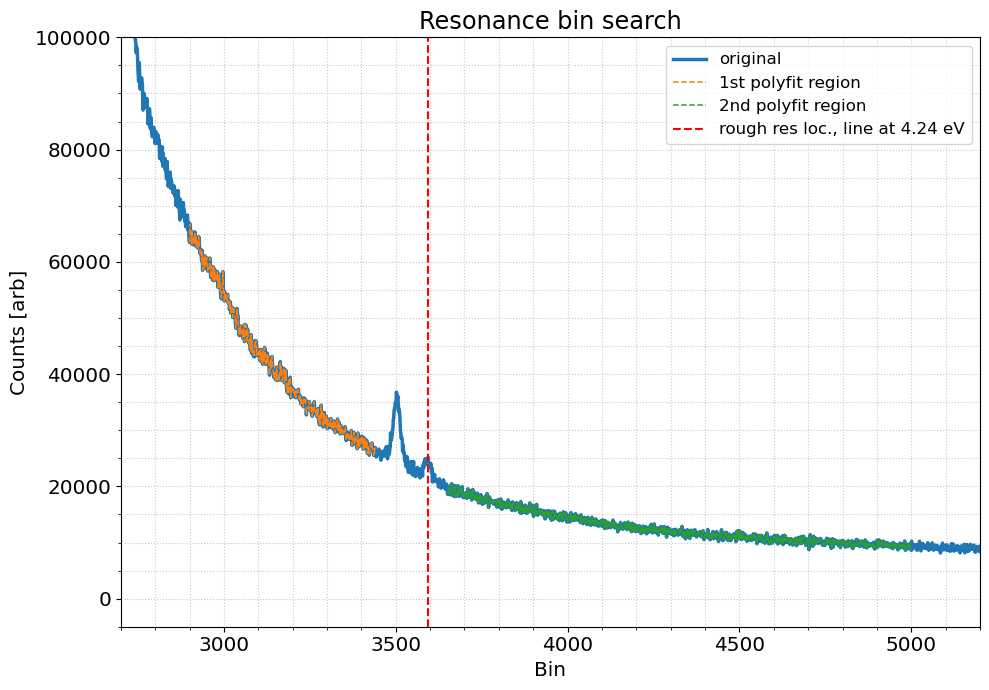

In [22]:
%matplotlib inline
plt.figure()

bg_region1_beg = 2900
bg_region1_end = 3440
bg_region2_beg = 3650
bg_region2_end = 5000
bg_reg1 = [bg_region1_beg,bg_region1_end]
bg_reg2 = [bg_region2_beg,bg_region2_end]
print(bg_reg1, bg_reg2)
fullrange = bg_reg2[1]-bg_reg1[0]
r = 199
ch = 10

start = time.time()
aft_res_reg = bg_reg2
bef_res_reg = bg_reg1

binstot = aft_res_reg[1]-bef_res_reg[0]  ## total number of bins in whole region
x1 = np.arange(bef_res_reg[0], bef_res_reg[1]+1,1)
x2 = np.arange(aft_res_reg[0], aft_res_reg[1]+1,1)
x = np.append(x1,x2)
print(x1[0], x1[-1])

fullx = np.arange(bef_res_reg[0], aft_res_reg[1],1) ## an array of every x bin in entire region
ys_bgsub = []

ys = all_D[r][ch]

fitdata1 = ys[bef_res_reg[0]: bef_res_reg[1]+1]
fitdata2 = ys[aft_res_reg[0]: aft_res_reg[1]+1]
datasplice = np.append(fitdata1, fitdata2)
y = datasplice
linecolors = ['lies','g','r','c','m','y']
f = 1
width = 2

plt.plot(ys, label = 'original', lw=width+0.5)
# plt.plot(fullx, ys[bef_res_reg[0]: aft_res_reg[1]]/f, label='region o interest')
plt.plot(x1, ys[x1[0]:x1[-1]+1]/f, label='1st polyfit region', ls = '--', lw=width-0.9)
plt.plot(x2, ys[x2[0]:x2[-1]+1]/f, label='2nd polyfit region', ls = '--', lw=width-0.9)
# x_eV = tof_to_eV(xpos, fpl, daq_delay)
lineeV = 4.24
linetof = eV_to_tof(lineeV, fpl, daq_delay)
linebin = np.where((xs>=(linetof-0.001)) & (xs<=(linetof+0.001)))[0][0]
print(linebin)
plt.axvline(x = linebin,ls = '--', c = 'r', label=f'rough res loc., line at {lineeV} eV')
plt.legend()
plt.title(f'Resonance bin search')
plt.ylabel('Counts [arb]',fontsize = 'x-large')
plt.xlabel('Bin',fontsize = 'x-large')
plt.ylim(-5000, 100000)
plt.xlim(bg_region1_beg-200, bg_region2_end+200)
plt.show()

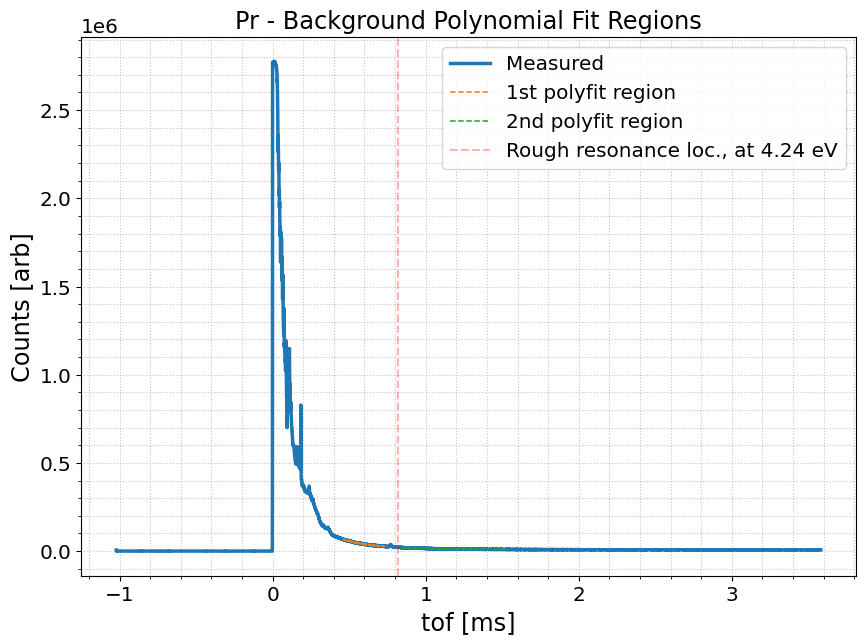

In [23]:
## redoing plot above for thesis
%matplotlib inline
plt.figure()
lw = 1.2
ls1 = 'xx-large'
ls2 = 'x-large'
plt.tight_layout(rect=[0.125, 0.130, 0.875, 0.920])  ## left bottom right 

plt.plot(xs, ys, label = 'Measured', lw=width+0.5)
# plt.plot(fullx, ys[bef_res_reg[0]: aft_res_reg[1]]/f, label='region o interest')
plt.plot(xs[x1], ys[x1[0]:x1[-1]+1]/f, label='1st polyfit region', ls = '--', lw=width-0.9)
plt.plot(xs[x2], ys[x2[0]:x2[-1]+1]/f, label='2nd polyfit region', ls = '--', lw=width-0.9)
plt.axvline(x = linetof, ls = '--', c = 'r',alpha = 0.30, label=f'Rough resonance loc., at {lineeV} eV')

plt.ylabel('Counts [arb]', fontsize=ls1)
plt.xlabel('tof [ms]', fontsize=ls1)
plt.tick_params(axis='x', labelsize = ls2)
plt.tick_params(axis='y', labelsize = ls2, labelcolor = 'black')
# plt.ylim(0, 5.0)
plt.title(r'Pr - Background Polynomial Fit Regions', fontsize = 'xx-large')

plt.grid(True, which='both',axis = 'both', alpha = 0.75, ls = ':')
plt.minorticks_on()
# plt.xticks(fontsize = 'xx-large')
# plt.yticks(fontsize = 'x-small')
# plt.legend(loc="center left", bbox_to_anchor=(0.12, 0.45))
plt.legend(fontsize = ls2)

# plt.legend(fontsize = 'medium')
plt.show()

In [24]:
print(eV_to_tof(4.24,fpl,0))

0.8184408713301381


In [25]:
## rebin helpers for the plotting
from functools import reduce

def factors(n):
    return set(reduce(list.__add__,
        ([i, n//i] for i in range(1, int(n**0.5) + 1) if n % i == 0)))

def rebin(ys, xs, rebinfactor):
    outys = ys.reshape(-1, rebinfactor).mean(axis=1)
    outxs = xs.reshape(-1, rebinfactor).mean(axis=1)
    return outys, outxs

In [26]:
# rebinfactors = np.sort(np.array(list(factors(len(y2)))))
# print(f'possible factors are ', rebinfactors)

# rebinf = rebinfactors[4]
# print(f'using factor {rebinf}')

possible factors are  [   1    2    4   11   22   43   44   86  172  473  946 1892]
using factor 4
order 2
Fitted Coefficients: [ 1.83182382e-04 -1.64985088e+00  3.80546085e+03]
Uncertainty:  [1.81124735e-06 1.42979285e-02 2.76625485e+01]
reduced chi squared:  17.200260569666014
residuals mean: 21.081866553742877

order 3
Fitted Coefficients: [-1.42482877e-07  1.87785796e-03 -8.27039929e+00  1.22909400e+04]
Uncertainty:  [1.51871252e-09 1.80794384e-05 7.08233422e-02 9.11904401e+01]
reduced chi squared:  3.0394511723508684
residuals mean: 8.784123527200748

order 4
Fitted Coefficients: [ 9.00846199e-11 -1.56788337e-06  1.02508200e-02 -2.99032324e+01
  3.30276545e+04]
Uncertainty:  [1.67414612e-12 2.65070383e-08 1.56018474e-04 4.04483068e-01
 3.89610239e+02]
reduced chi squared:  1.1999064153290249
residuals mean: 5.253678800628016

order 5
Fitted Coefficients: [-5.89907953e-14  1.25432348e-09 -1.06840986e-05  4.56437675e-02
 -9.80239377e+01  8.50221210e+04]
Uncertainty:  [3.06237265e-15

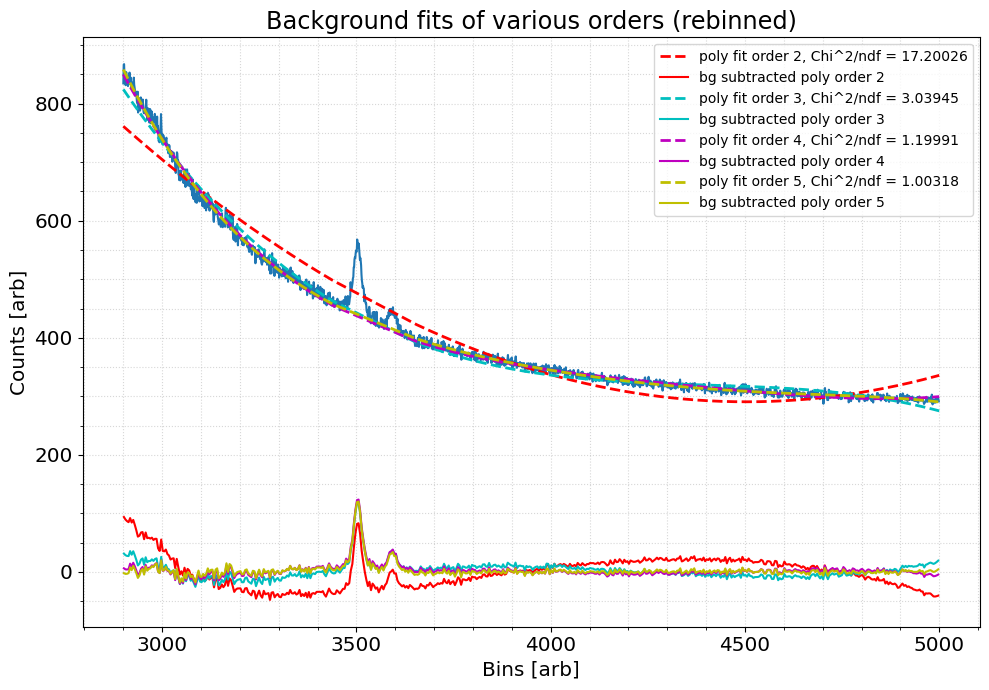

12.591813087463379 sec


In [27]:
## plot different orders of polynomial
## Rerun cell above before re-running this one
# %matplotlib qt
plt.figure()

linecolors = ['lies','g','r','c','m','y']
f = 100
plotoffset = 200

plt.plot(fullx, ys[bef_res_reg[0]: aft_res_reg[1]]/f+plotoffset)
rebinfactors = np.sort(np.array(list(factors(len(y)))))
print(f'possible factors are ', rebinfactors)

rebinf = rebinfactors[2]
print(f'using factor {rebinf}')

allchi2 = []

y_scaled = (y)/f
# x = x_scaled  ## try this for reasonable chi2 values
y = y_scaled
sigma = np.full_like(x, 1)

coeffs, errs, chi2, residuals = polyN_fit_chi2_w2(x,y,sigma,5) ## use residuals from 5th order poly as sigmas
sigma_from_resid = np.full_like(y_scaled, np.std(residuals))
sigma = sigma_from_resid

for i in (range(2,6)):
    # Fit model
    print(f'order {i}')
#     coeffs, errs, chi2 = polyN_fit_chi2(x,y,i)
    coeffs, errs, chi2 = polyN_fit_chi2_w(x,y,sigma,i)
#     coeffs, errs, chi2, residuals = polyN_fit_chi2_w2(x,y,sigma,i)
#     sigma_from_resid = np.full_like(y_scaled, np.std(residuals))
#     coeffs, errs, chi2, residuals = polyN_fit_chi2_w2(x,y,sigma_from_resid,i)
    print("Fitted Coefficients:", coeffs)
    print('Uncertainty: ', errs)
    print('reduced chi squared: ', chi2)
    y_fit = polyN_predict(x, coeffs)
    # res = polyN_residuals(x, y, coeffs)
    # print("residuals:", res)
    fullpoly_y2 = polyN_predict(fullx, coeffs)

    ys_bgsub=[]
    bgsubtracted = ys[bef_res_reg[0]:aft_res_reg[1]]/f - fullpoly_y2  ## subtracts RealData-BackgroundFit
    ys_bgsub.append(bgsubtracted)
    # ys_bgsub[0] ## the array notation is left over from before...
    chi2 = np.round(chi2,5)
    plt.plot(x, y_fit+plotoffset, label = rf'poly fit order {i}, Chi^{2}/ndf = {chi2}', ls = '--', c=linecolors[i], lw = '2')
#     plt.plot(fullx, ys_bgsub[0], label = rf'bg subtracted poly order {i}',c=linecolors[i])
    y_plotrebin, xs_plotrebin = rebin(ys_bgsub[0], fullx, rebinf)
    plt.plot(xs_plotrebin,y_plotrebin, label = rf'bg subtracted poly order {i}',c=linecolors[i])
    # print(("max y:", np.max(y)))
    # print("residuals:", y - y_fit)
    print("residuals mean:", np.mean(np.abs(y - y_fit)))
    print()

plt.title(rf'Background fits of various orders (rebinned)', fontsize = 'xx-large')
# plt.xticks(np.arange(-1.0,4.0, 0.5),fontsize = 'large')
plt.grid(True, which='both', alpha = 0.5, ls = ':')
plt.minorticks_on()
plt.xticks(fontsize = 'x-large')
plt.yticks(fontsize = 'x-large')
plt.ylabel('Counts [arb]',fontsize = 'x-large')
plt.xlabel('Bins [arb]',fontsize = 'x-large')
plt.legend(fontsize = 'medium')
plt.show()
end = time.time()
print(end-start, 'sec')
# plt.plot(x, y_fit)

## use this !!

In [28]:
bg_region1_beg = 2900
bg_region1_end = 3440
bg_region2_beg = 3650
bg_region2_end = 5000
bg_reg1 = [bg_region1_beg,bg_region1_end]
bg_reg2 = [bg_region2_beg,bg_region2_end]
print(bg_reg1, bg_reg2)
fullrange = bg_reg2[1]-bg_reg1[0]

## change to 2nd order poly in cleaned up version
start = time.time()

# @njit
def bg_fitsubtract_noseq(bef_res_reg, aft_res_reg, ys, order): ## before/after resonance region [start:end] respectively, ys[ch] to fit
    binstot = aft_res_reg[1]-bef_res_reg[0]  ## total number of bins in whole region
    x1 = np.arange(bef_res_reg[0], bef_res_reg[1],1)
    x2 = np.arange(aft_res_reg[0], aft_res_reg[1],1)
    x = np.append(x1,x2)
    fullx = np.arange(bef_res_reg[0], aft_res_reg[1],1) ## an array of every x bin in entire region
    ys_bgsub = []
    fitdata1 = ys[bef_res_reg[0]: bef_res_reg[1]]
    fitdata2 = ys[aft_res_reg[0]: aft_res_reg[1]]
    datasplice = np.append(fitdata1, fitdata2)
    y = datasplice
    
    coeffs, errs = polyN_fit_errors(x, y,order) # use new fit functions 
#     print("Fitted Coefficients:", coeffs)
#     print('Uncertainty ', errs)
    y_fit = polyN_predict(x, coeffs) ## run the function with the coeff you just found
    fullpoly_y2 = polyN_predict(fullx, coeffs)
    
    bgsubtracted = ys[bef_res_reg[0]:aft_res_reg[1]] - fullpoly_y2  ## subtracts RealData-BackgroundFit
    ys_bgsub.append(bgsubtracted)
    return ys_bgsub[0] ## the array notation is left over from before...

## background subtraction currently only for NaI detectors
num_fittingchs = numchannels-1  ## removes the Li detector, assumes it is there
print(num_fittingchs)
bgsub_D = np.zeros((numruns_tot_D, num_fittingchs,fullrange), dtype = np.float64) ## num runs, channels, range of bg_ subtraction
bgsub_U = np.zeros((numruns_tot_U, num_fittingchs,fullrange), dtype = np.float64) ## num runs, channels, range of bg_ subtraction
times3 = []
polyorder = 5
addtimes=0
for r in range(0, len(all_D)): ## for every run
#     print(r)
    start = time.time()
    if r == 0 or r==100 or r==200 or r==300 or r==400 or r==500 or r==len(all_D)-1:
        print(rf'run {r}, '+'100 runs took '+str(addtimes))
        addtimes=0
    for ch in range(0, num_fittingchs): ## and every channel (except 6Li)
        if channels_D[ch] == 'ch_24':
            emessage = ('bg_ fit does not work for 6Li yet')
            logger.error('run '+run_num + emessage)
            raise Exception(emessage)
#         print(r, ch)
#         print(channels[ch])
#         print(len(bgsub_D[r][ch]))
#         print(len(all_D[r][ch]))
        bgsub_D[r][ch] = bg_fitsubtract_noseq(bg_reg1,bg_reg2, all_D[r][ch], polyorder)
        bgsub_U[r][ch] = bg_fitsubtract_noseq(bg_reg1,bg_reg2, all_U[r][ch], polyorder)
    end = time.time()
    addtimes = addtimes+(end-start)
    times3.append(end-start)
#     print('run took '+str(end-start))

[2900, 3440] [3650, 5000]
12
run 0, 100 runs took 0
run 100, 100 runs took 24.573445558547974
run 200, 100 runs took 22.594378232955933
run 300, 100 runs took 22.878820180892944
run 400, 100 runs took 22.757625818252563
run 447, 100 runs took 10.828990936279297


In [29]:
# r = 128
# ch = 9
# ydata = bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]
# ydata2 = bgsub_U[r+1][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]

# plt.plot(ydata)
# plt.plot(ydata2)

# plt.plot(bg_reg1[-1])

In [30]:

# res_region_beg = 3560
# res_region_end = 3630
# res_reg = [res_region_beg,res_region_end]
# xdata = xs[res_reg[0]:res_reg[1]]
# print(xdata)
# print(len(bgsub_D[0][0]), (bg_reg2[1]-bg_reg1[0]))
# print(res_reg[0]-bg_reg1[0])
# newresstart = res_reg[0]-bg_reg1[0]
# newresend = (res_reg[1]-res_reg[0])+newresstart
# plt.plot(bgsub_D[0][0])
# plt.plot(bgsub_D[0][0][newresstart:newresend])

In [31]:
plt.figure()

r = 7
ch =3

res_region_beg = 3300
res_region_end = 3800
res_reg = [res_region_beg,res_region_end]
newresstart = res_reg[0]-bg_reg1[0]
newresend   = (res_reg[1]-res_reg[0])+newresstart

xdata = xs[res_reg[0]:res_reg[1]]
# ydata = bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]
ydata = bgsub_D[r][ch][newresstart:newresend]
ydata_np = bgsub_D[r][ch][newresstart:newresend]
# plt.plot(ydata)

<Figure size 1000x700 with 0 Axes>

[5.00000000e-03 4.33543514e-03 8.16783398e-01 4.63643188e+01]
[[ 8.25606920e-06 -1.01324717e-05  9.27233080e-09 -1.71330684e-02]
 [-1.01324717e-05  1.34395152e-05 -1.30381569e-08  2.42991050e-02]
 [ 9.27233080e-09 -1.30381569e-08  3.64125459e-07 -2.55113297e-05]
 [-1.71330684e-02  2.42991050e-02 -2.55113297e-05  5.26029803e+01]]
2078.5443107261794
116.21811247598038
3699.337415472438
9272.86376302358
971.7767496926477
[ 968.5535694  1135.61047867 1394.83443453  509.20761135  402.58229779
  893.03179822 1747.06139772  606.33431195  512.83774582  205.68586289]


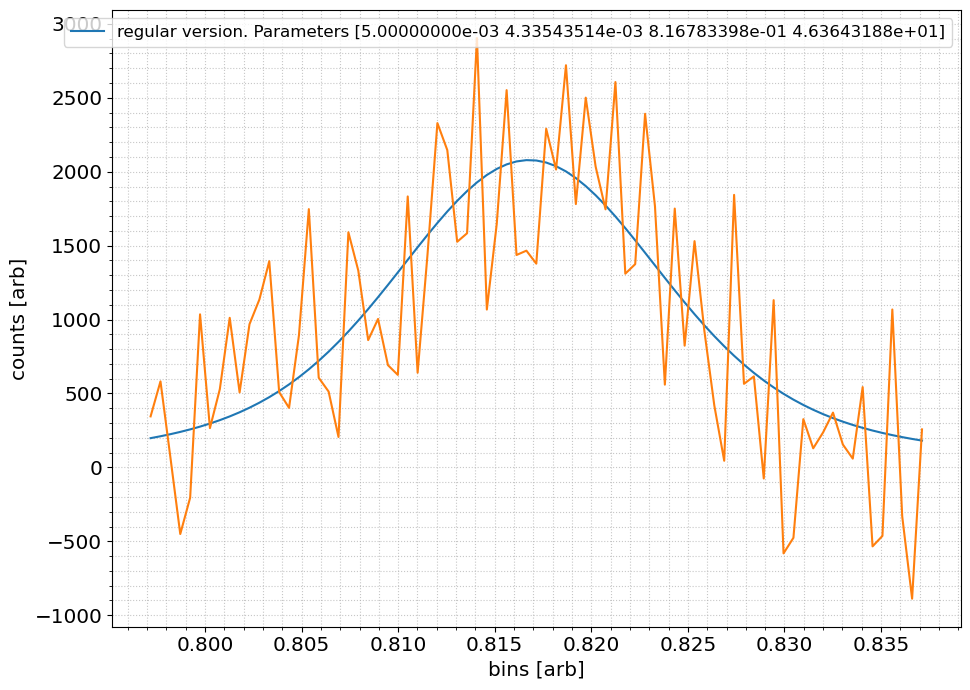

In [32]:
## look at fitting manually
# %matplotlib inline
plt.figure()

r = 90
ch = 3

res_region_beg = 3553
res_region_end = 3632
res_reg = [res_region_beg,res_region_end]
newresstart = res_reg[0]-bg_reg1[0]
newresend   = (res_reg[1]-res_reg[0])+newresstart

xdata = xs[res_reg[0]:res_reg[1]]
# ydata = bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]
ydata = bgsub_U[r][ch][newresstart:newresend]
ydata_np = bgsub_U[r][ch][newresstart:newresend]

def voigt2(x, sig, gam, xshift, amp):
#     xshift=1.9678
    fit = voigt_profile(x-xshift, sig, gam)*amp
    return fit

# popt, pcov = curve_fit(voigt2, xdata, ydata)
# popt, pcov = curve_fit(voigt2, xdata, ydata, bounds = ([0,0,0.79,-np.inf], [np.inf,np.inf,0.85, np.inf]))
# popt, pcov = curve_fit(voigt2, xdata, ydata, bounds = ([0,0,0,-np.inf], [np.inf,np.inf,np.inf, np.inf]))
# popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0025,0.005,0.815,100], bounds = ([0.0005,0,0.79,-np.inf], [np.inf,np.inf,0.83, np.inf]))
# popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.004,0.006,0.8175,100], bounds = ([0.0024,0.0002,0.813,0], [0.005,0.012,0.823, np.inf])) 
popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.003,0.005,0.8175,100], bounds = ([0.001,0.002,0.813,0], [0.005,0.007,0.823, np.inf])) 

# popt_np, pcov_np = curve_fit(voigt2, xdata, ydata_np, bounds = ([0,0,0,-np.inf], [np.inf,np.inf,np.inf, np.inf]))

print(popt)
print(pcov)

fitted_curve = voigt2(xdata, popt[0],popt[1],popt[2],popt[3],)
# fitted_curve_np = voigt2(xdata, popt_np[0],popt_np[1],popt_np[2],popt_np[3],)

print(max(fitted_curve))
print((popt[3])*np.sqrt(2*np.pi))
print((popt[3])/(np.sqrt(2*np.pi)*popt[0]))
print((popt[3])/(popt[0]))
print(sum(fitted_curve)*(popt[0]*np.sqrt(2*np.pi)))

print(ydata[10:20])## this plots the other res too
ydata2 =  bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]
xtest = xs[bg_reg1[1]:bg_reg2[0]]

plt.plot(xdata,fitted_curve, label = f'regular version. Parameters {popt}')
# plt.plot(fitted_curve_np, label = 'np version', ls='--')

# plt.plot(xs, ON_bgsub[1][0])
plt.legend()
plt.plot(xdata,ydata)
plt.ylabel('counts [arb]',fontsize = 'x-large')
plt.xlabel('bins [arb]',fontsize = 'x-large')
plt.show()

resonance at  4.248726297904008 eV


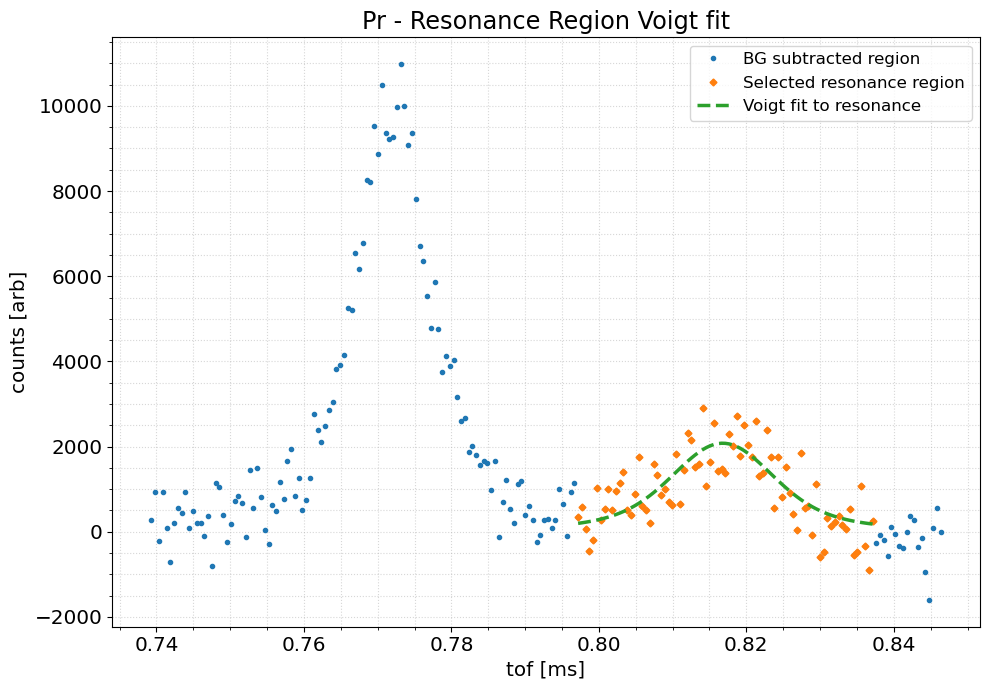

In [33]:
## same as above replotted for other res, thesis
%matplotlib inline
plt.figure()
tofres = 0.8176
print('resonance at ', tof_to_eV(tofres, fpl, 0), 'eV')

ydata2 =  bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]
xdata2 = xs[bg_reg1[1]:bg_reg2[0]]
plt.plot(xdata2, ydata2, label='BG subtracted region', ls='none', marker='o', ms = 3.0)
plt.plot(xdata,ydata,label='Selected resonance region', ls='none', marker='D', ms = 3.5)

plt.plot(xdata, fitted_curve, label = 'Voigt fit to resonance', ls = '--', lw=2.5)
# plt.plot(xdata, fitted_curve_np, label = 'np version', ls='--')
# ydata = bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]

plt.title(rf'Pr - Resonance Region Voigt fit', fontsize = 'xx-large')
# plt.xticks(np.arange(-1.0,4.0, 0.5),fontsize = 'large')
plt.grid(True, which='both', alpha = 0.5, ls = ':')
plt.minorticks_on()
plt.xticks(fontsize = 'x-large')
plt.yticks(fontsize = 'x-large')
plt.ylabel('counts [arb]',fontsize = 'x-large')
plt.xlabel('tof [ms]',fontsize = 'x-large')
plt.legend(fontsize = 'large')
plt.show()

# automate voigt

In [34]:
# now voigt
start = time.time()

def voigt2(x, sig, gam, xshift, amp):
    fit = voigt_profile(x-xshift, sig, gam)*amp
    return fit

res_region_beg = 3553
res_region_end = 3632
res_reg = [res_region_beg,res_region_end]
newresstart = res_reg[0]-bg_reg1[0]
newresend   = (res_reg[1]-res_reg[0])+newresstart
new_res_reg = [newresstart, newresend]  ## this just realigns in terms of bins. Probably a nicer way to do it.

if res_reg[0] < bg_reg1[1] or res_reg[1]>bg_reg2[0]:
    emessage = ('Declared Background region and Resonance region have overlapping fitting regions')
    logger.error('run '+run_num + emessage)
    raise Exception(emessage)

# resonance region is assumed to be in between 2 background regions. Could maybe change this. 11.22.24
 
def voigt_fitting_noseq2(ogbin_res_reg, aftbin_res_reg, xs,ys): ##new res reg is the region after bin shifting by background region
    ## p0 below seems to get rid of some trouble
    xdata = xs[ogbin_res_reg[0]:ogbin_res_reg[1]]
    ydata = ys[aftbin_res_reg[0]:aftbin_res_reg[1]]
    # popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0032,0.0048,0.8175,50], bounds = ([0.0005,0.0005,0.813,0], [0.009,0.012,0.825, np.inf]))  ##change these values for the current target!!
    # popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.004,0.006,0.8175,50], bounds = ([0.0000,0.0000,0.813,0], [0.009,0.012,0.823, np.inf]))  ##change these values for the current target!!
    # popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0032,0.003,0.8175,50], bounds = ([0.0031,0.0000,0.813,0], [0.0034,0.014,0.823, np.inf]))  ##change these values for the current target!!
    popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0026,0.0048,0.8175,50], bounds = ([0.0,0.0046,0.813,0], [np.inf,0.0051,0.823, np.inf]))  ##change these values for the current target!!
    fitted_curve = voigt2(xdata, popt[0],popt[1],popt[2],popt[3],)
    fit_params = popt
    fit_errs = np.diagonal(pcov)
    parameters=[fit_params,fit_errs]
    return fitted_curve, parameters ## keep same notation as before..
#     return fit_curves[0], parameters[0] ## keep same notation as before..

def voigt_fitting_noseq3(ogbin_res_reg, aftbin_res_reg, xs,ys): ## change the bounds on this one accordinglhy if needed
    ## p0 below seems to get rid of some trouble
    xdata = xs[ogbin_res_reg[0]:ogbin_res_reg[1]]
    ydata = ys[aftbin_res_reg[0]:aftbin_res_reg[1]]
    # popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0032,0.0048,0.8175,50], bounds = ([0.0005,0.0005,0.813,0], [0.009,0.012,0.825, np.inf]))  ##change these values for the current target!!
    # popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.004,0.006,0.8175,50], bounds = ([0.0000,0.0000,0.813,0], [0.009,0.012,0.823, np.inf]))  ##change these values for the current target!!
    popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0032,0.00,0.8175,50], bounds = ([0.0031,0.0000,0.813,0], [0.0034,0.014,0.823, np.inf]))  ##change these values for the current target!!
        # popt, pcov = curve_fit(voigt2, xdata, ydata,p0=[0.0026,0.0048,0.8175,50], bounds = ([0.0,0.0046,0.813,0], [np.inf,0.0051,0.823, np.inf]))  ##change these values for the current target!!
    fitted_curve = voigt2(xdata, popt[0],popt[1],popt[2],popt[3],)
    fit_params = popt
    fit_errs = np.diagonal(pcov)
    parameters=[fit_params,fit_errs]
    return fitted_curve, parameters ## keep same notation as before..

######################################### new
res_size = res_reg[1]-res_reg[0] 
voigt_D = np.zeros((numruns_tot_D, num_fittingchs,res_size), dtype = np.float64) ## num runs, channels, range of voigt
voigt_U = np.zeros((numruns_tot_U, num_fittingchs,res_size), dtype = np.float64) ## num runs, channels, range of voigt

v_params_D = np.zeros((numruns_tot_D, num_fittingchs,2,4), dtype = np.float64) ## channels, sequences,[params, param_errs], [sigma, gamma, shift, amp thing]
v_params_U = np.zeros((numruns_tot_U, num_fittingchs,2,4), dtype = np.float64)

## these below are for a constrained gam or sig
voigt_D3 = np.zeros((numruns_tot_D, num_fittingchs,res_size), dtype = np.float64) ## num runs, channels, range of voigt
voigt_U3 = np.zeros((numruns_tot_U, num_fittingchs,res_size), dtype = np.float64) ## num runs, channels, range of voigt

v_params_D3 = np.zeros((numruns_tot_D, num_fittingchs,2,4), dtype = np.float64) ## channels, sequences,[params, param_errs], [sigma, gamma, shift, amp thing]
v_params_U3 = np.zeros((numruns_tot_U, num_fittingchs,2,4), dtype = np.float64)


## CHANGED FOR NEW REGIONS 08.07.25
# times3 = []
addtimes=0
for r in range(0, len(bgsub_D)): ## for every run    
# for r in range(0, 100):    ## FOR TESTING
#     print(r)
    start = time.time()
    if r == 0 or r==100 or r==200 or r==300 or r==400 or r==500 or r==len(bgsub_D)-1:
        print(rf'run {r}, '+'100 runs took '+str(addtimes))
        addtimes=0
    for ch in range(0, num_fittingchs): ## and every channel (except 6Li)
        if channels_D[ch] == 'ch_24':
            emessage = ('v fit does not work for 6Li yet')
            logger.error('run '+run_num + emessage)
            raise Exception(emessage)
#         print(r, ch)
#         print(channels[ch])
#         print(len(bgsub_D[r][ch]))
#         print(len(all_D[r][ch]))
        try:
            voigt_D[r][ch], v_params_D[r][ch] = voigt_fitting_noseq2(res_reg,new_res_reg,xs, bgsub_D[r][ch]) ## this currently constrains gam
            voigt_U[r][ch], v_params_U[r][ch] = voigt_fitting_noseq2(res_reg,new_res_reg,xs, bgsub_U[r][ch])
            voigt_D3[r][ch], v_params_D3[r][ch] = voigt_fitting_noseq3(res_reg,new_res_reg,xs, bgsub_D[r][ch]) ## and this constrains sig
            voigt_U3[r][ch], v_params_U3[r][ch] = voigt_fitting_noseq3(res_reg,new_res_reg,xs, bgsub_U[r][ch])
        except Exception as e:
            print('run ', r, 'chan ', ch)
            print("An error occurred:", e)
    end = time.time()
    addtimes = addtimes+(end-start)
#     times3.append(end-start)
#     print('run took '+str(end-start))


run 0, 100 runs took 0
run 100, 100 runs took 23.170528888702393
run 200, 100 runs took 21.99898600578308
run 300, 100 runs took 23.242961168289185
run 400, 100 runs took 22.357137203216553
run 447, 100 runs took 10.174671411514282


In [35]:
plt.rcParams.update({
    'legend.fontsize': 'large',
    'grid.alpha': '0.65',
})
# %matplotlib qt
print('updated rcparam')

updated rcparam


0.003289413321421079
0.0007178142823312214
[array([-23.79144341,   9.55425184,  11.84740283, ...,   7.71533073,
         4.22156389,   0.92926974], shape=(2100,))]
0.6117737293243408 sec


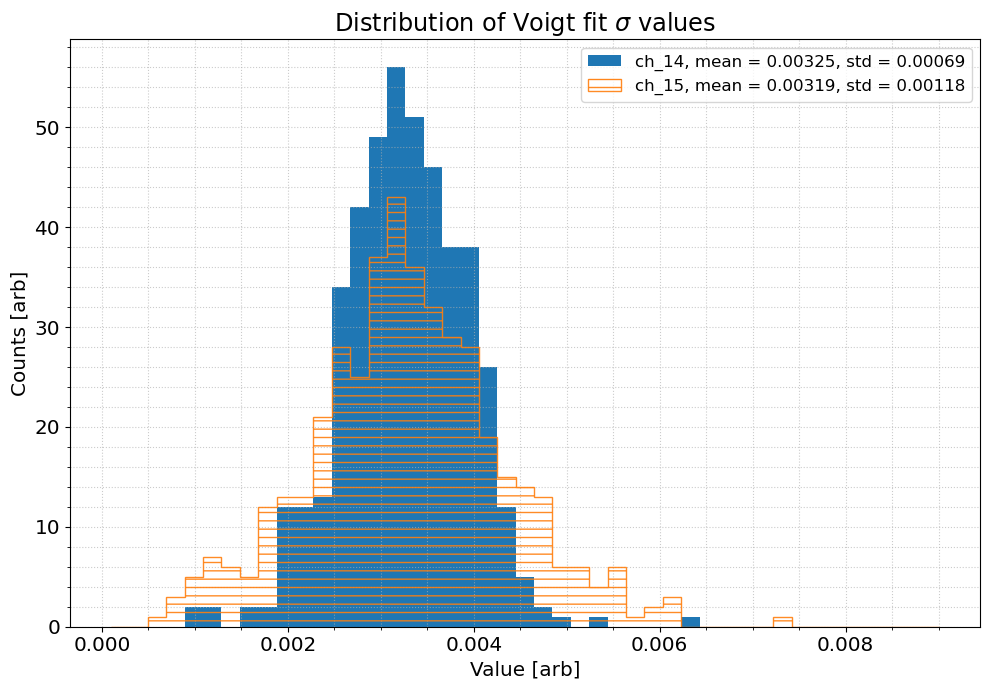

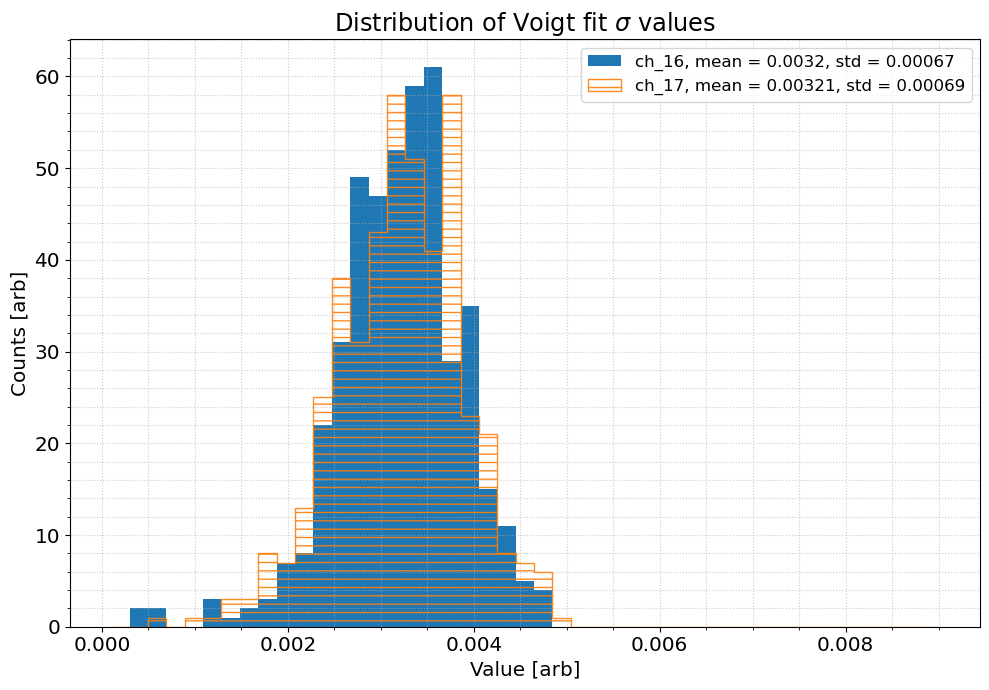

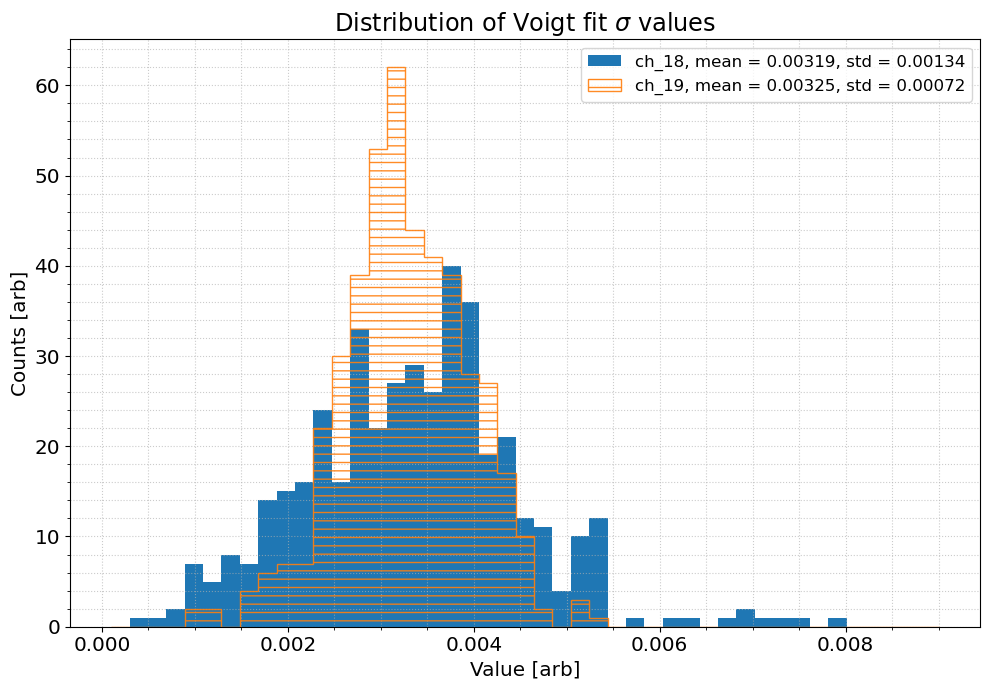

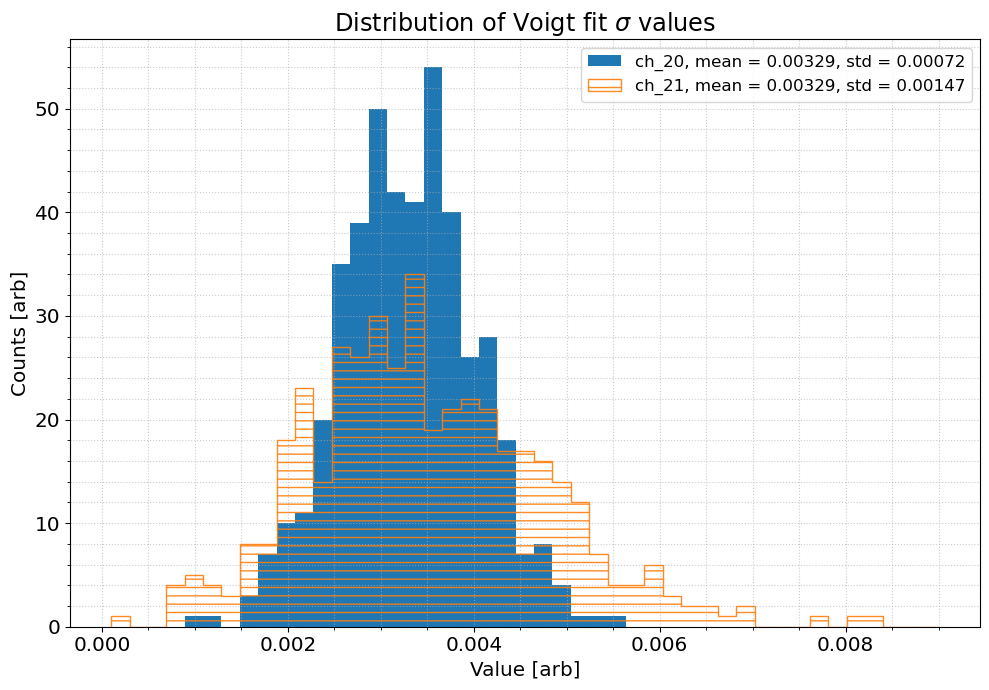

In [36]:
## sigma
## all runs, select channel, 0th array [param values, not erros], and parameter p
# %matplotlib inline
ran = [0.0001,0.009]
b = 100
p = 0
key = 'up'
if key == 'up':
    vdata = v_params_U
    chleg = channels_U
if key == 'dn':
    vdata = v_params_D
    chleg = channels_D

ch = 2
fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\sigma$ values')
# plt.title(rf'Distribution of Voigt fit $\sigma$ values', fontsize = 'xx-large')
mean = np.round(np.average(vdata[:,ch,0,0]),5)
std = np.round(np.std(vdata[:,ch,0,0]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,0]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,0]),5)
plt.hist(vdata[:,ch,0,0], bins =45, range = ran,  label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,0], bins =45, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\sigma$ values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\sigma$ values', fontsize = 'xx-large')
mean = np.round(np.average(vdata[:,ch,0,0]),5)
std = np.round(np.std(vdata[:,ch,0,0]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,0]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,0]),5)
plt.hist(vdata[:,ch,0,0], bins =45, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,0], bins =45, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\sigma$ values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\sigma$ values', fontsize = 'xx-large')
mean = np.round(np.average(vdata[:,ch,0,0]),5)
std = np.round(np.std(vdata[:,ch,0,0]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,0]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,0]),5)
plt.hist(vdata[:,ch,0,0], bins =45, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,0], bins =45, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\sigma$ values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\sigma$ values', fontsize = 'xx-large')
mean = np.round(np.average(vdata[:,ch,0,0]),5)
std = np.round(np.std(vdata[:,ch,0,0]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,0]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,0]),5)
plt.hist(vdata[:,ch,0,0], bins =45, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,0], bins =45, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value

print(np.average(vdata[:,ch,0,0]))
print(np.std(vdata[:,ch,0,0]))

plt.legend()
# plt.show()

print(ys_bgsub)

end = time.time()
print(end-start, 'sec')

0.0032194891965464955
0.00014534678857117654


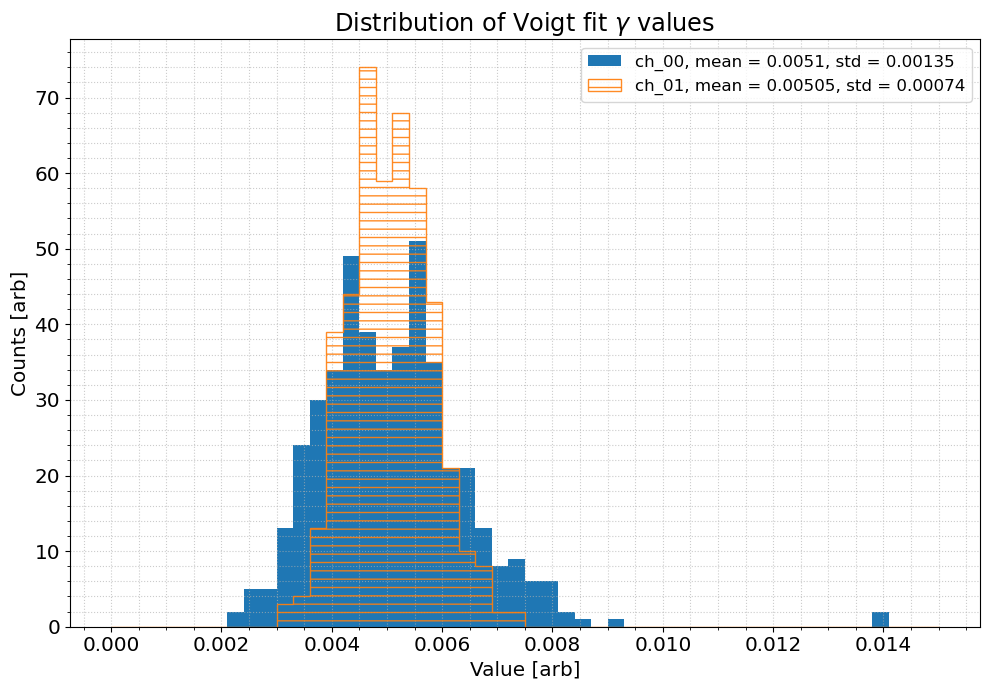

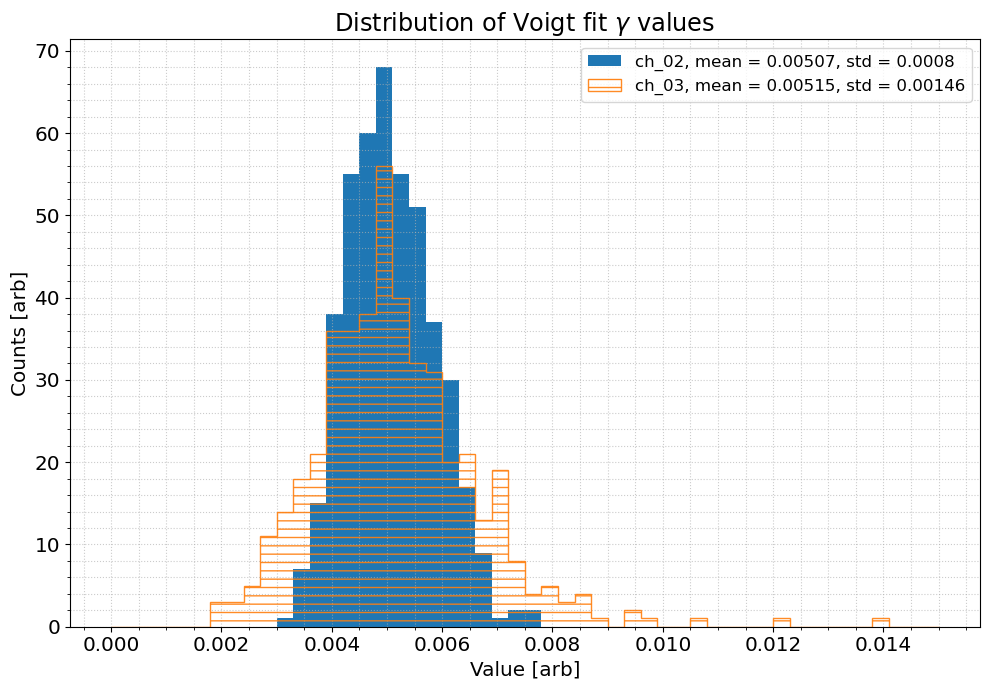

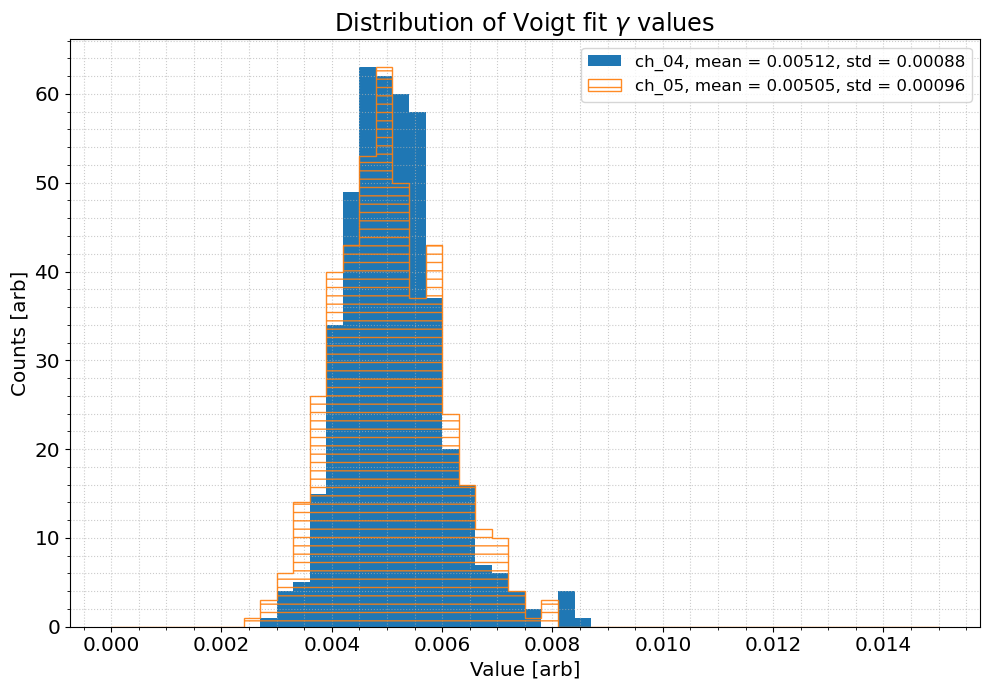

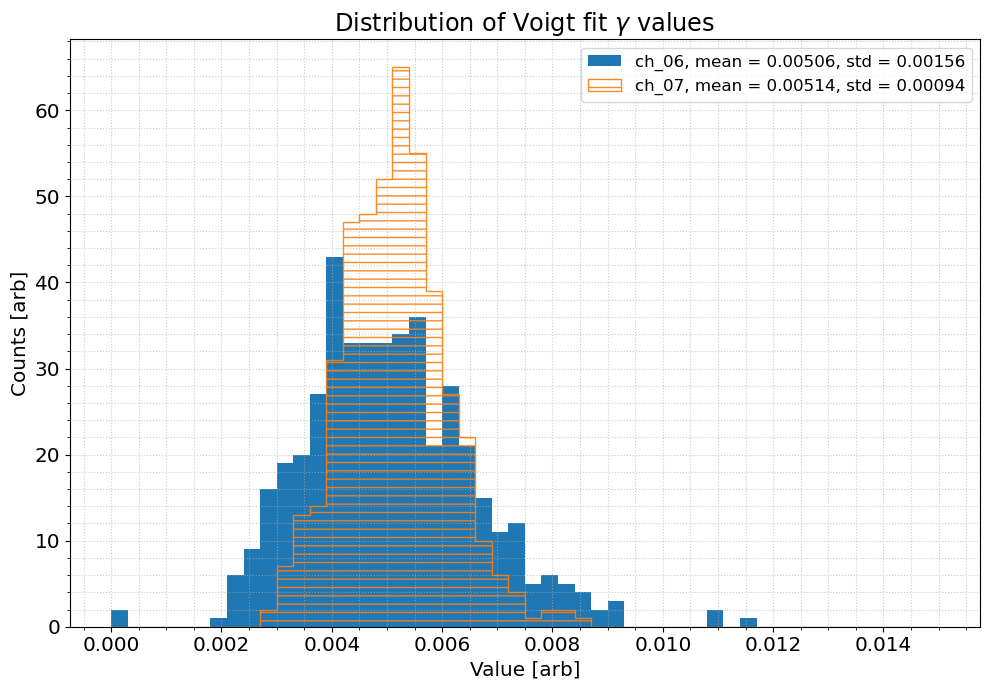

[array([-23.79144341,   9.55425184,  11.84740283, ...,   7.71533073,
         4.22156389,   0.92926974], shape=(2100,))]
4.980356216430664 sec


In [37]:
## new gamma
 ## all runs, select channel, 0th array [param values, not erros], and parameter p
ran = [0.00,0.015]
b = 50
p = 1
key = 'dn'
if key == 'up':
    vdata = v_params_U3
    chleg = channels_U
if key == 'dn':
    vdata = v_params_D3
    chleg = channels_D

ch = 0
fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\gamma$ values')
# plt.ylabel('Counts [arb]',fontsize = 'x-large')
# plt.xlabel('Values [arb]',fontsize = 'x-large')
mean = np.round(np.average(vdata[:,ch,0,p]),5) 
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran,  label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\gamma$ values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\gamma$ values', fontsize = 'xx-large')
# plt.ylabel('Counts [arb]',fontsize = 'x-large')
# plt.xlabel('Values [arb]',fontsize = 'x-large')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\gamma$ values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\gamma$ values', fontsize = 'xx-large')
# plt.ylabel('Counts [arb]',fontsize = 'x-large')
# plt.xlabel('Values [arb]',fontsize = 'x-large')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $\gamma$ values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\gamma$ values', fontsize = 'xx-large')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

print(np.average(vdata[:,ch,0,0]))
print(np.std(vdata[:,ch,0,0]))

plt.show()

print(ys_bgsub)
end = time.time()
print(end-start, 'sec')

0.003189273070245665
0.0013353387021366222


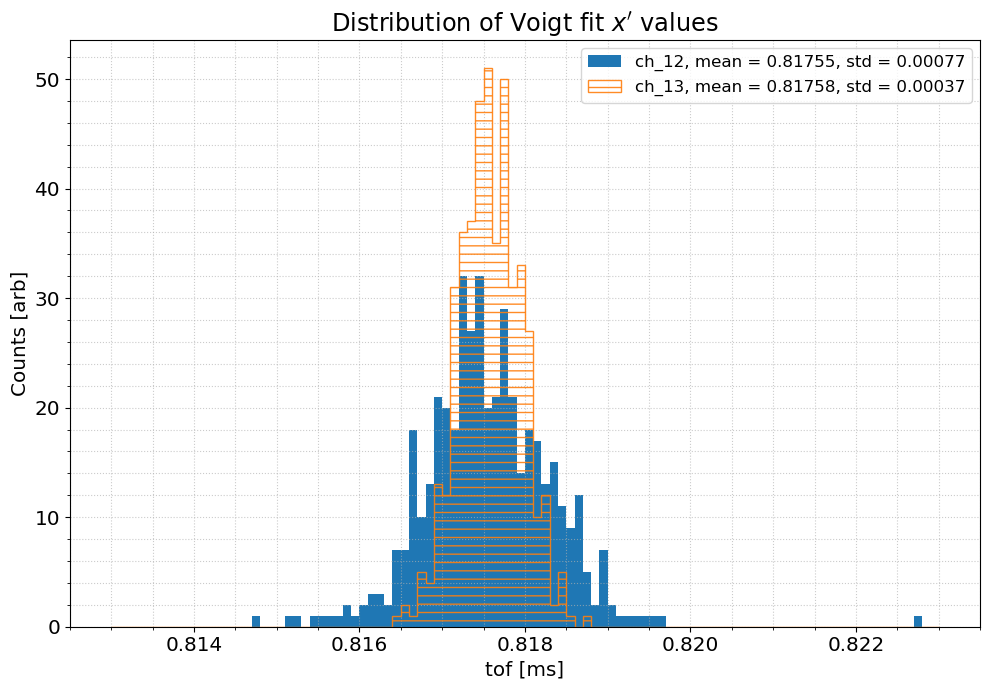

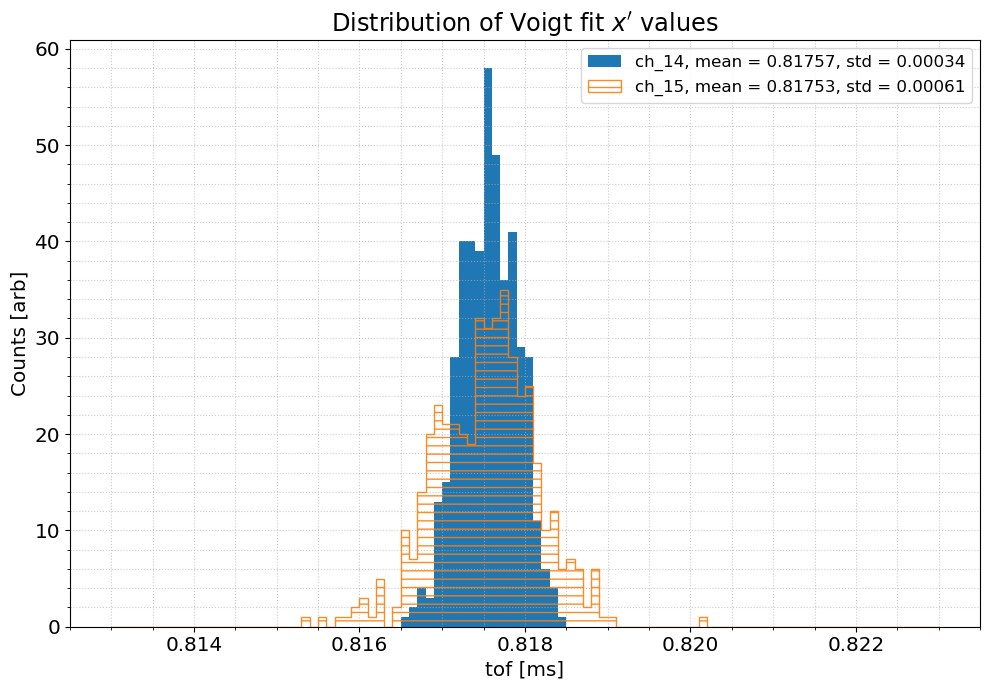

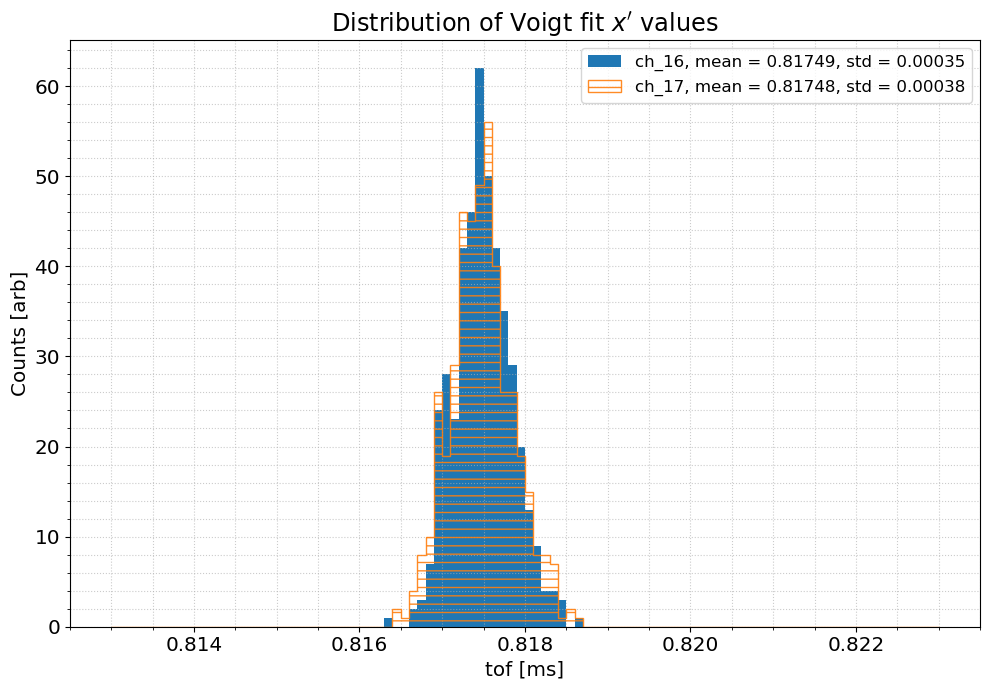

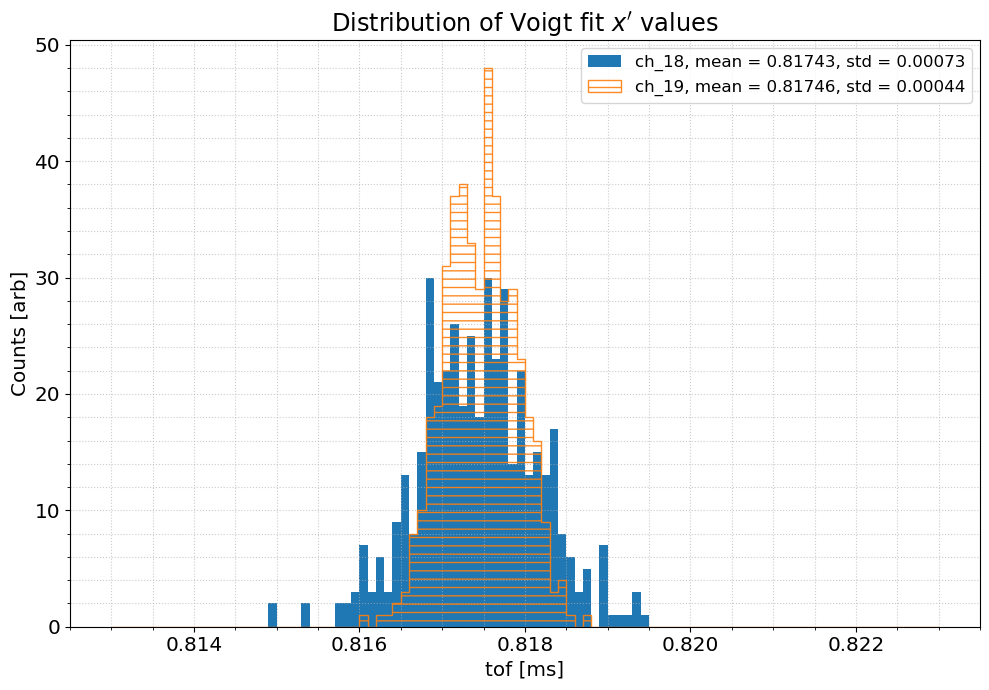

[array([-23.79144341,   9.55425184,  11.84740283, ...,   7.71533073,
         4.22156389,   0.92926974], shape=(2100,))]
7.134089946746826 sec


In [38]:
## new xshift
## all runs, select channel, 0th array [param values, not erros], and parameter p
%matplotlib inline
ran = [0.813,0.823]
b = 100
p = 2
key = 'up'
if key == 'up':
    vdata = v_params_U
    chleg = channels_U
if key == 'dn':
    vdata = v_params_D
    chleg = channels_D

ch = 0
fig, ax = plt.subplots()
ax.set(xlabel='tof [ms]', ylabel='Counts [arb]',title=r'Distribution of Voigt fit $x^\prime$ values')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran,  label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

ch=ch+2
fig, ax = plt.subplots()
ax.set(xlabel='tof [ms]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $x^\prime$ values')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

ch=ch+2
fig, ax = plt.subplots()
ax.set(xlabel='tof [ms]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $x^\prime$ values')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

ch=ch+2
fig, ax = plt.subplots()
ax.set(xlabel='tof [ms]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit $x^\prime$ values')
mean = np.round(np.average(vdata[:,ch,0,p]),5)
std = np.round(np.std(vdata[:,ch,0,p]),5)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),5)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),5)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

print(np.average(vdata[:,ch,0,0]))
print(np.std(vdata[:,ch,0,0]))

plt.show()

print(ys_bgsub)

end = time.time()
print(end-start, 'sec')

0.003189273070245665
0.0013353387021366222


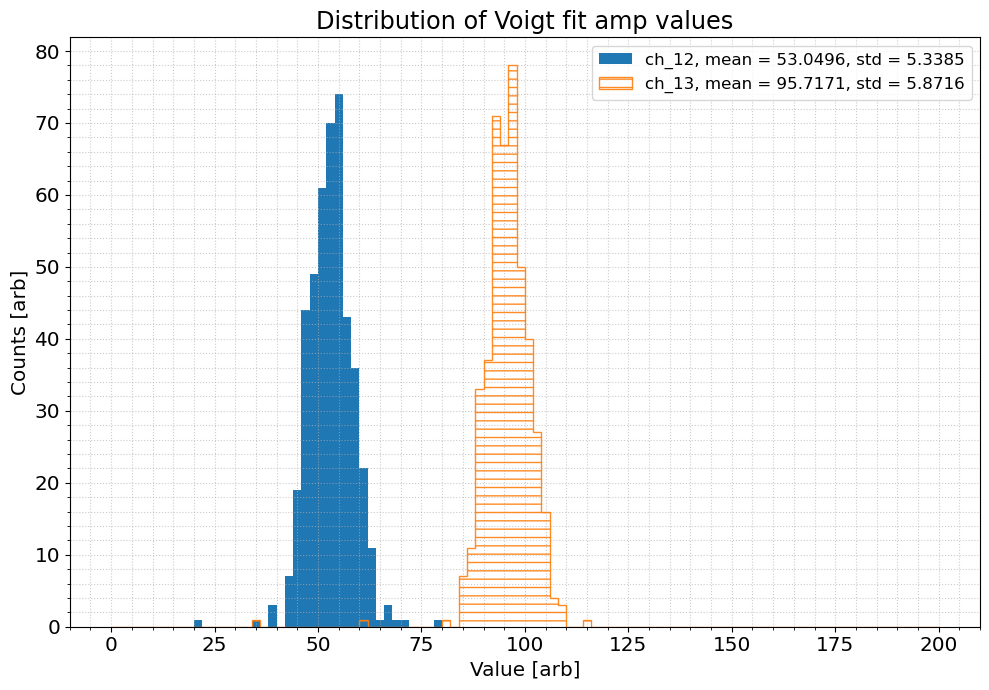

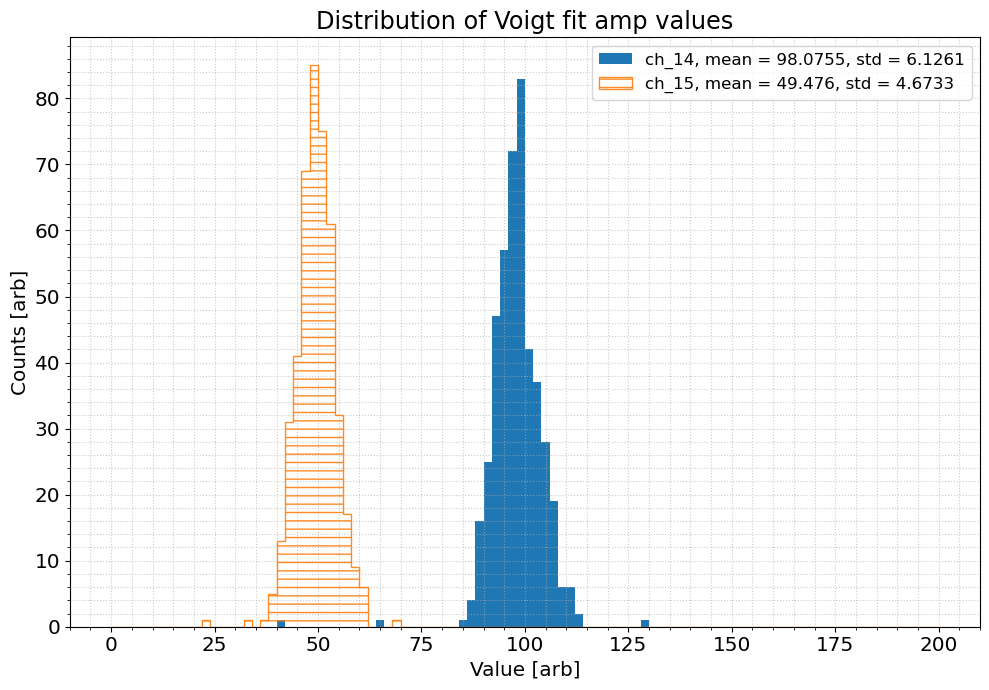

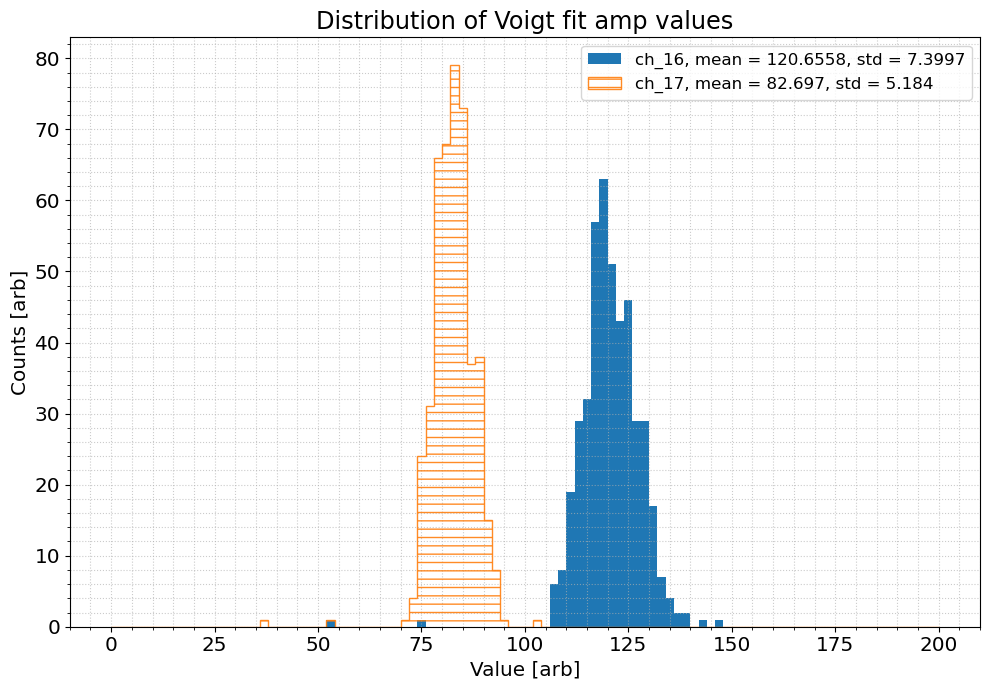

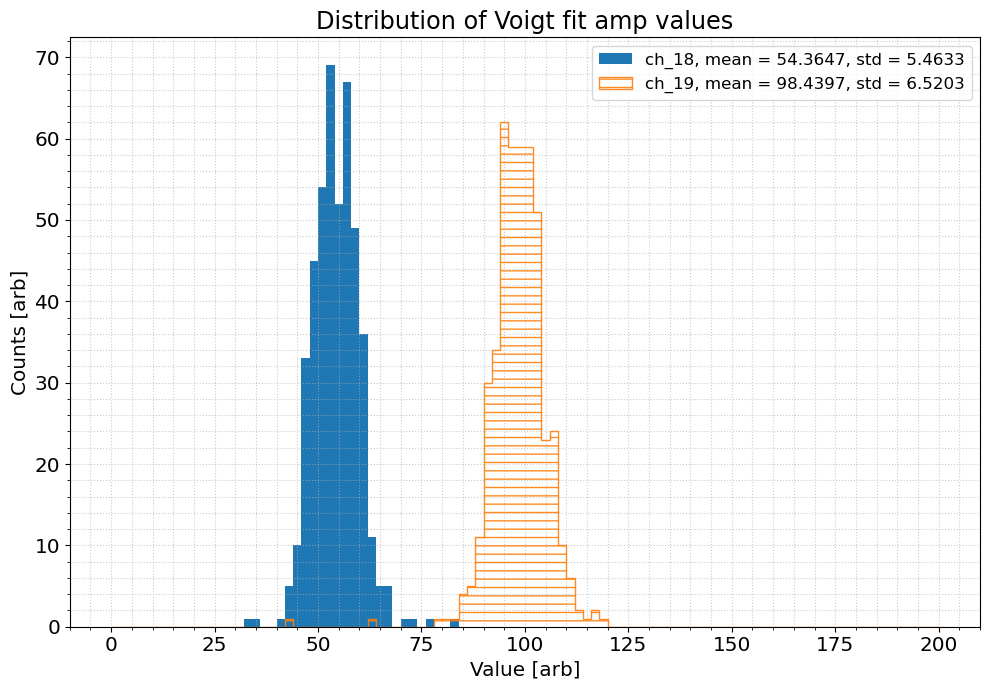

[array([-23.79144341,   9.55425184,  11.84740283, ...,   7.71533073,
         4.22156389,   0.92926974], shape=(2100,))]
9.624738216400146 sec


In [39]:
## new amp. Just to get an idea for p0 guess
 ## all runs, select channel, 0th array [param values, not erros], and parameter p
ran = [0.00,200]
b = 100
p = 3
key = 'up'
if key == 'up':
    vdata = v_params_U
    chleg = channels_U
if key == 'dn':
    vdata = v_params_D
    chleg = channels_D

ch = 0
fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit amp values')
# plt.ylabel('Counts [arb]',fontsize = 'x-large')
# plt.xlabel('Values [arb]',fontsize = 'x-large')
mean = np.round(np.average(vdata[:,ch,0,p]),4) 
std = np.round(np.std(vdata[:,ch,0,p]),4)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),4)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),4)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran,  label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit amp values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\gamma$ values', fontsize = 'xx-large')
# plt.ylabel('Counts [arb]',fontsize = 'x-large')
# plt.xlabel('Values [arb]',fontsize = 'x-large')
mean = np.round(np.average(vdata[:,ch,0,p]),4)
std = np.round(np.std(vdata[:,ch,0,p]),4)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),4)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),4)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit amp values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\gamma$ values', fontsize = 'xx-large')
# plt.ylabel('Counts [arb]',fontsize = 'x-large')
# plt.xlabel('Values [arb]',fontsize = 'x-large')
mean = np.round(np.average(vdata[:,ch,0,p]),4)
std = np.round(np.std(vdata[:,ch,0,p]),4)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),4)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),4)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

fig, ax = plt.subplots()
ax.set(xlabel='Value [arb]', ylabel='Counts [arb]',title=rf'Distribution of Voigt fit amp values')
ch=ch+2
# plt.title(rf'Distribution of Voigt fit $\gamma$ values', fontsize = 'xx-large')
mean = np.round(np.average(vdata[:,ch,0,p]),4)
std = np.round(np.std(vdata[:,ch,0,p]),4)
mean2 = np.round(np.average(vdata[:,ch+1,0,p]),4)
std2 = np.round(np.std(vdata[:,ch+1,0,p]),4)
plt.hist(vdata[:,ch,0,p], bins =b, range = ran, label = chleg[ch]+rf', mean = {mean}, std = {std}')  ## all runs, ch, parameters array, sigma value
# plt.figure()
plt.hist(vdata[:,ch+1,0,p], bins =b, range = ran, alpha =0.9, hatch='--',histtype='step', label = chleg[ch+1]+rf', mean = {mean2}, std = {std2}')  ## all runs, ch, parameters array, sigma value
plt.legend()

print(np.average(vdata[:,ch,0,0]))
print(np.std(vdata[:,ch,0,0]))

plt.show()

print(ys_bgsub)
end = time.time()
print(end-start, 'sec')

In [40]:
print(len(v_params_D))
print(len(v_params_D[0]))
print(len(v_params_D[0][0]))
print(len(v_params_D[0][0][0]))

num_v_params = len(v_params_D[0][0][0])-1 ## -1 because we exclude the 'amplitude' parameter that will be left varying
v_params_mean_D = np.zeros((num_fittingchs,2,num_v_params), dtype = np.float64) ## num channels, [param, std], num parameters
v_params_mean_U = np.zeros((num_fittingchs,2,num_v_params), dtype = np.float64) ## num channels, [param, std], num parameters


448
12
2
4


In [41]:
ch =8
print(channels_U[ch])
p = 0
print(len((v_params_U[:,ch,0,0])))
print(np.round(np.average(v_params_U[:,ch,0,p]),5))
rounded_arr_2dp = np.round(v_params_U[:,ch,0,p], decimals=4)
print(len(rounded_arr_2dp))
print((v_params_U[:,ch,0,p][0:10]))
print((rounded_arr_2dp[0:10]))
mode_D = st.mode(v_params_U[:,ch,1,p], keepdims = False)
print(mode_D)
mode_D = st.mode(rounded_arr_2dp, keepdims = False)
print(mode_D)

ch_20
448
0.00329
448
[0.00369783 0.00433922 0.00295166 0.00248579 0.00238759 0.00223324
 0.00354861 0.00478153 0.00378971 0.00306194]
[0.0037 0.0043 0.003  0.0025 0.0024 0.0022 0.0035 0.0048 0.0038 0.0031]
ModeResult(mode=np.float64(1.0924074144078691e-06), count=np.int64(1))
ModeResult(mode=np.float64(0.0035), count=np.int64(30))


In [42]:
print(len(v_params_D[0][0]))
print((v_params_D[0][0]))

2
[[1.21772867e-09 5.10000000e-03 8.18866499e-01 5.22951141e+01]
 [1.13573890e+05 1.72879927e-06 1.43210055e-07 2.65324025e+01]]


In [43]:
#this is original v_params saving
## now loop through and record the mean, mode, and std of each parameter
start = time.time()
num_v_params = len(v_params_D[0][0][0])-1 ## -1 because we exclude the 'amplitude' parameter that will be left varying
v_params_mean_D = np.zeros((num_fittingchs,3,num_v_params), dtype = np.float64) ## num channels, [p_mean,p_mode,std], num parameters
v_params_mean_U = np.zeros((num_fittingchs,3,num_v_params), dtype = np.float64) ## num channels, [p_mean,p_mode,std], num parameters
print(len(v_params_mean_D))
print(len(v_params_mean_D[0]))
print(len(v_params_mean_D[0][0]))

for ch in range(0, num_fittingchs): ## and every channel (except 6Li)
    if channels_D[ch] == 'ch_24':
        emessage = ('bg_ fit does not work for 6Li yet')
        logger.error('run '+run_num + emessage)
        raise Exception(emessage)
    for param in range(0, num_v_params):
#         print(r, ch)
#         print(channels[ch])
#         print(len(bgsub_D[r][ch]))
#         print(len(all_D[r][ch]))
        mean_D = np.average(v_params_D[:,ch,0,param]) ## just easier to read # 0 indicates the parameter mean
        mean_U = np.average(v_params_U[:,ch,0,param])
        std_D = np.std(v_params_D[:,ch,0,param]) ## just easier to read # 2 indicates the parameter std as
        std_U = np.std(v_params_U[:,ch,0,param])
        rounded_arr_D = np.round(v_params_D[:,ch,0,param], decimals=4)  ##just picked decimal 4 arbitrarily. But might work.
        rounded_arr_U = np.round(v_params_U[:,ch,0,param], decimals=4)
        mode_D = st.mode(rounded_arr_D, keepdims = False) ## just easier to read # 1 indicates the parameter mode
        mode_U = st.mode(rounded_arr_U, keepdims = False)
        v_params_mean_D[ch][0][param] = mean_D
        v_params_mean_D[ch][1][param] = mode_D[0]
        v_params_mean_D[ch][2][param] = std_D
        v_params_mean_U[ch][0][param] = mean_U
        v_params_mean_U[ch][1][param] = mode_U[0]
        v_params_mean_U[ch][2][param] = std_U

end = time.time()
print('time ', (end-start))

12
3
3
time  0.038537025451660156


In [44]:
# now instead frankenstein 2 seperate v_params together... for Pr the distributions work better when constraining sig or gam
## now loop through and record the mean, mode, and std of each parameter
start = time.time()
num_v_params = len(v_params_D[0][0][0])-1 ## -1 because we exclude the 'amplitude' parameter that will be left varying
v_params_mean_D = np.zeros((num_fittingchs,3,num_v_params), dtype = np.float64) ## num channels, [p_mean,p_mode,std], num parameters
v_params_mean_U = np.zeros((num_fittingchs,3,num_v_params), dtype = np.float64) ## num channels, [p_mean,p_mode,std], num parameters

v_params_mean_D3 = np.zeros((num_fittingchs,3,num_v_params), dtype = np.float64) ## num channels, [p_mean,p_mode,std], num parameters
v_params_mean_U3 = np.zeros((num_fittingchs,3,num_v_params), dtype = np.float64) ## num channels, [p_mean,p_mode,std], num parameters
print(len(v_params_mean_D))
print(len(v_params_mean_D[0]))
print(len(v_params_mean_D[0][0]))

for ch in range(0, num_fittingchs): ## and every channel (except 6Li)
    if channels_D[ch] == 'ch_24':
        emessage = ('bg_ fit does not work for 6Li yet')
        logger.error('run '+run_num + emessage)
        raise Exception(emessage)
    for param in range(0, num_v_params):
#         print(r, ch)
#         print(channels[ch])
#         print(len(bgsub_D[r][ch]))
#         print(len(all_D[r][ch]))
        mean_D = np.average(v_params_D[:,ch,0,param]) ## just easier to read # 0 indicates the parameter mean
        mean_U = np.average(v_params_U[:,ch,0,param])
        std_D = np.std(v_params_D[:,ch,0,param]) ## just easier to read # 2 indicates the parameter std as
        std_U = np.std(v_params_U[:,ch,0,param])
        rounded_arr_D = np.round(v_params_D[:,ch,0,param], decimals=4)  ##just picked decimal 4 arbitrarily. But might work.
        rounded_arr_U = np.round(v_params_U[:,ch,0,param], decimals=4)
        mode_D = st.mode(rounded_arr_D, keepdims = False) ## just easier to read # 1 indicates the parameter mode
        mode_U = st.mode(rounded_arr_U, keepdims = False)

        mean_D3 = np.average(v_params_D3[:,ch,0,param]) ## just easier to read # 0 indicates the parameter mean
        mean_U3 = np.average(v_params_U3[:,ch,0,param])
        std_D3 = np.std(v_params_D3[:,ch,0,param]) ## just easier to read # 2 indicates the parameter std as
        std_U3 = np.std(v_params_U3[:,ch,0,param])
        rounded_arr_D3 = np.round(v_params_D3[:,ch,0,param], decimals=4)  ##just picked decimal 4 arbitrarily. But might work.
        rounded_arr_U3 = np.round(v_params_U3[:,ch,0,param], decimals=4)
        mode_D3 = st.mode(rounded_arr_D3, keepdims = False) ## just easier to read # 1 indicates the parameter mode
        mode_U3 = st.mode(rounded_arr_U3, keepdims = False)
        
        v_params_mean_D[ch][0][param] = mean_D
        v_params_mean_D[ch][1][param] = mode_D[0]
        v_params_mean_D[ch][2][param] = std_D
        v_params_mean_U[ch][0][param] = mean_U
        v_params_mean_U[ch][1][param] = mode_U[0]
        v_params_mean_U[ch][2][param] = std_U

        v_params_mean_D3[ch][0][param] = mean_D3
        v_params_mean_D3[ch][1][param] = mode_D3[0]
        v_params_mean_D3[ch][2][param] = std_D3
        v_params_mean_U3[ch][0][param] = mean_U3
        v_params_mean_U3[ch][1][param] = mode_U3[0]
        v_params_mean_U3[ch][2][param] = std_U3

end = time.time()
print('time ', (end-start))

12
3
3
time  0.06615447998046875


In [60]:
# # checking mean/mode/std outputs

# for ch in range(0,12):
# #     ch = 10
#     p=1
#     mean = np.average(v_params_D[:,ch,0,p])
#     std = np.std(v_params_D[:,ch,0,p])
#     mode_D = st.mode(np.round(v_params_D[:,ch,0,p], decimals=4), keepdims = False)
#     print(mean)
#     print(mode_D)
#     print(std)
#     print()
#     print(v_params_mean_D[ch][0][p])
#     print(v_params_mean_D[ch][1][p])
#     print(v_params_mean_D[ch][2][p])
#     print('--')


In [61]:
# # checking mean/mode/std outputs

# for ch in range(0,12):
# #     ch = 10
#     p=1
#     mean3 = np.average(v_params_D3[:,ch,0,p])
#     std3 = np.std(v_params_D3[:,ch,0,p])
#     mode_D3 = st.mode(np.round(v_params_D3[:,ch,0,p], decimals=4), keepdims = False)
#     print(mean3)
#     print(mode_D3)
#     print(std3)
#     print()
#     print(v_params_mean_D3[ch][0][p])
#     print(v_params_mean_D3[ch][1][p])
#     print(v_params_mean_D3[ch][2][p])
#     print('--')


In [62]:
## now combine 2 diff v_params
print(v_params_mean_D.shape)
# print(v_params_mean_D[:,:,1]) ## gamma [mean, mode, std] from the constrained gamma fitting. all D channels
# print(v_params_mean_D3[:,:,1]) ## gamma [mean, mode, std] from the free gamma fitting. all D channels
# print(v_params_mean_D[:,2])

## replace the gamma of the constrained gamma array (regular mean_D, not mean_D3)
v_params_mean_D[:,:,1] = v_params_mean_D3[:,:,1]
v_params_mean_U[:,:,1] = v_params_mean_U3[:,:,1]
print(v_params_mean_D[:,:,1])
print('checking done')

(12, 3, 3)
[[0.00509953 0.0056     0.00135277]
 [0.00505001 0.0046     0.00074301]
 [0.00506714 0.0049     0.0007989 ]
 [0.0051528  0.0048     0.00146194]
 [0.00511958 0.0047     0.00088174]
 [0.00504563 0.0051     0.00096225]
 [0.0050583  0.0044     0.00156193]
 [0.00514418 0.0054     0.00093525]
 [0.00500703 0.0043     0.00091853]
 [0.00514775 0.0052     0.00146934]
 [0.00496872 0.0048     0.0008498 ]
 [0.00497021 0.005      0.00078188]]
checking done


In [63]:
print(len(v_params_mean_D))
print(len(v_params_mean_D[0]))
print(len(v_params_mean_D[0][0]))

# print(v_params_mean_D[9:])
# print('----------------')
# print(v_params_mean_U[0:3])
# print()
v_params_mean_all = np.vstack((v_params_mean_D,v_params_mean_U))
print(len(v_params_mean_all))
print(len(v_params_mean_all[0]))
print(len(v_params_mean_all[0][0]))
# print(v_params_mean_all[9:])

12
3
3
24
3
3


In [64]:
## checking

# for ch in range(0,12):
# #     ch = 10
#     p=0
# #     mean = np.average(v_params_D[:,ch,0,p])
# #     std = np.std(v_params_D[:,ch,0,p])
# #     mode_D = st.mode(np.round(v_params_D[:,ch,0,p], decimals=4), keepdims = False)
# #     print(mean)
# #     print(mode_D)
# #     print(std)
#     print()
#     print(v_params_mean_U[ch][0][p])
#     print(v_params_mean_U[ch][1][p])
#     print(v_params_mean_U[ch][2][p])
#     print()
#     print(v_params_mean_all[ch+12][0][p])
#     print(v_params_mean_all[ch+12][1][p])
#     print(v_params_mean_all[ch+12][2][p])
#     print('--')

In [65]:
# print(channels_all)
# print(len(v_params_mean_all))
# # print((v_params_mean_all[0][0]))
# print(v_params_mean_all[-1,:,2])

In [66]:
# ## save out vfit params to hdf5

# # bg_reg1_bef = [bg_region1_beg,bg_region1_end]
# # bg_reg2_aft = [bg_region2_beg,bg_region2_end]

# with h5py.File(vconstantsavename+'.h5', 'w') as hdf5_file:
#     hdf5_file.attrs['bg_reg_bef'] = bg_reg1 ## adding the puck information
#     hdf5_file.attrs['bg_reg_aft'] = bg_reg2 ## adding the puck information
#     hdf5_file.attrs['res_reg'] = res_reg ## will be empty if puck is not in (usually)
# #     hdf5_file.attrs['num_pulses'] = numRuns ## some runs do not have 5000 pulses! Usually the ones at the end
# #     hdf5_file.attrs['sequences'] = len(sequence[0])
#     for ch in range(0,len(v_params_mean_all)): ## change this to length of asymms!
#         Ch_grp = hdf5_file.create_group(channels_all[ch])
#         Ch_grp.attrs['sigma_[mean,mode,std]']   = v_params_mean_all[ch,:,0]
#         Ch_grp.attrs['gamma_[mean,mode,std]']   = v_params_mean_all[ch,:,1]
#         Ch_grp.attrs['res_loc_[mean,mode,std]'] = v_params_mean_all[ch,:,2]

In [67]:
import sys

def sizeof_fmt(num, suffix='B'):
    ''' by Fred Cirera,  https://stackoverflow.com/a/1094933/1870254, modified'''
    for unit in ['','Ki','Mi','Gi','Ti','Pi','Ei','Zi']:
        if abs(num) < 1024.0:
            return "%3.1f %s%s" % (num, unit, suffix)
        num /= 1024.0
    return "%.1f %s%s" % (num, 'Yi', suffix)

for name, size in sorted(((name, sys.getsizeof(value)) for name, value in list(
                          locals().items())), key= lambda x: -x[1])[:10]:
    print("{:>30}: {:>8}".format(name, sizeof_fmt(size)))


                       bgsub_D: 86.1 MiB
                       bgsub_U: 86.1 MiB
                   rolled_ch_D: 30.7 MiB
                   rolled_ch_U: 30.7 MiB
                       voigt_D:  3.2 MiB
                       voigt_U:  3.2 MiB
                      voigt_D3:  3.2 MiB
                      voigt_U3:  3.2 MiB
                       spectra:  1.7 MiB
                     spectra_D: 913.4 KiB


#### now try plotting P_n overlaid with the resonance

In [68]:
## redefining resonance regions. I think it got lost somewhere
# xtof_forPn = xs[res_reg[0]:res_reg[1]]
xtof_forPn = xdata2
# ydata_forPn = bgsub_U[r][ch][newresstart:newresend]
ydata_forPn = ydata2


La res (checking) roughly at  0.7370550416182776 eV
This resonance roughly at  0.8176 ms or  4.217717573163684 eV
tau_up = 36.2539  tau_down = 78.9824
gamma_SE:  0.014922190783063642
Best P_He:  0.540987612430111
guess P_Rb:  0.8
"some factor":  0.4
estimate P_n for 4.24 eV resonance: 0.03785242371617163
estimate P_n for La 0.7 eV resonance: 0.09297559692707882


Text(0.5, 0, 'eV')

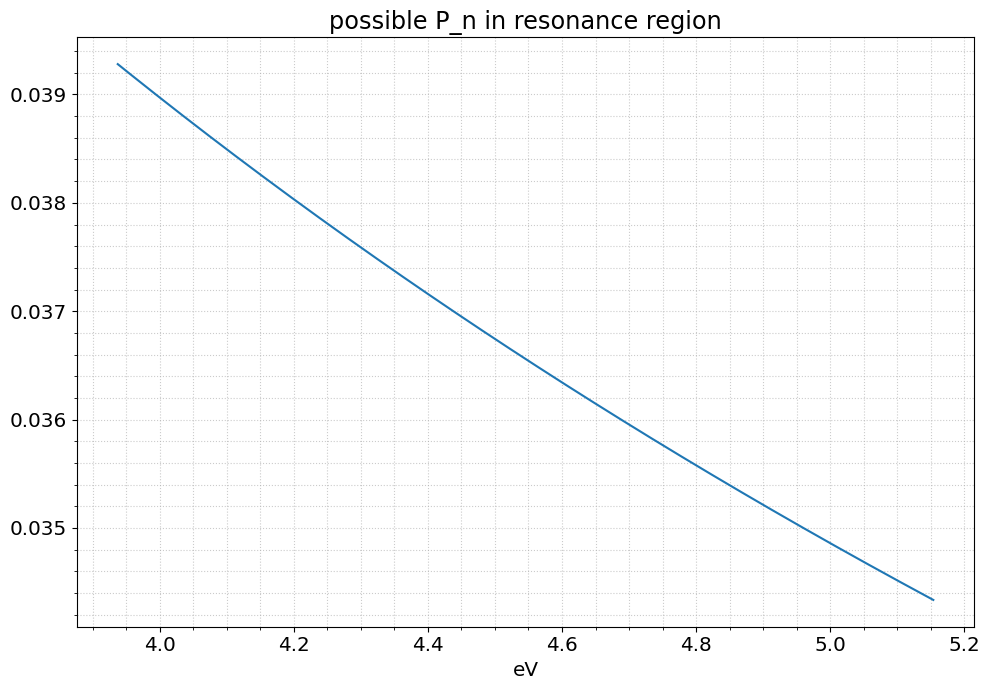

In [69]:
# print(tu, td)
tau_up = 36.2539
tau_dn = 78.9824
g_se = 1/tau_up - 1/tau_dn
P_he = g_se/(1/tau_up)
P_rb = 0.8
f = 0.4
# tofres = 0.8176  ## defined earlier
fpl2 = 23.31
delay2 = 0.003 #ms
print('La res (checking) roughly at ', tof_to_eV(1.96, fpl2, delay2), 'eV')  # I recall it is ~1.96 ms
print('This resonance roughly at ',tofres, 'ms or ', tof_to_eV(tofres, fpl2, delay2), 'eV')

print('tau_up =', tau_up, ' tau_down =',tau_dn)
print('gamma_SE: ',g_se)
print('Best P_He: ',P_he)
print('guess P_Rb: ', P_rb)
print('"some factor": ', f)

## EQUATION: P_n = tanh(n*sigma_0*l*lambda*P_He) 
# number density n = 3.197*10^19 1/cm^3 (2 bar cell), cell length l = 11 cm, absorption cross section for 1 A sigma_0 = ~3000 barns

n = 4.91*10**(19) #1/cm^3
l = 10.8 #cm
sigma_0 = 2970*10**(-24) #barns to cm^2
testlamb = 0.1389  ## Angstrom. just googling roughly what wavelength is for 4.24 eV
testPn = np.tanh(n*sigma_0*l*testlamb*P_he*P_rb*f)
print(f'estimate P_n for 4.24 eV resonance: {testPn}')
testLaPn = np.tanh(n*sigma_0*l*0.342*P_he*P_rb*f)  ## printing Pn at La resonance to check
print(f'estimate P_n for La 0.7 eV resonance: {testLaPn}')

h = 6.62607015e-34  ## joule-seconds
m = 1.67492749804e-27 ## kg
eV_to_J = 1.602176565e-19 ## conversion factor
m_to_A = 1e10 ## m to Angstrom converstion factor

E_res_forPn = tof_to_eV(xtof_forPn, fpl2, delay2)  ## res region in E 
p_res_forPn = np.sqrt(2*m*E_res_forPn*eV_to_J)  ## momentum in res region I think
lamb_res_forPn = h/p_res_forPn*m_to_A
P_n_res = np.tanh(n*sigma_0*l*lamb_res_forPn*P_he*P_rb*f)

plt.title('possible P_n in resonance region')
plt.plot(E_res_forPn, P_n_res)
# plt.axvline(x = E_res[50], ls = '--', c = 'r')
# plt.axhline(y = np.tanh(n*sigma_0*l*lamb_res[50]*P_he*P_rb*f), ls = '--', c = 'r')
plt.xlabel('eV')


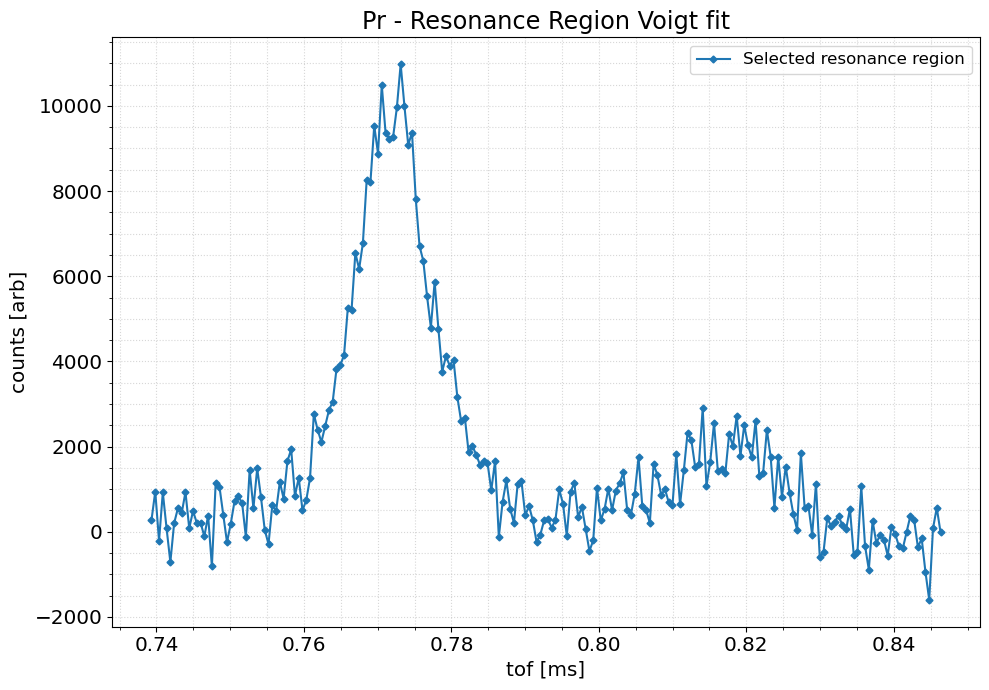

In [70]:
## plotting cell redone to check resonance
%matplotlib inline
plt.figure()

# ydata2 =  bgsub_U[r][ch][bg_reg1[1]-bg_reg1[0]:bg_reg2[0]-bg_reg1[0]]
# xdata2 = xs[bg_reg1[1]:bg_reg2[0]]
# plt.plot(xdata2, ydata2, label='BG subtracted region', ls='none', marker='o', ms = 3.0)
plt.plot(xtof_forPn, ydata_forPn,label='Selected resonance region', ls='-', marker='D', ms = 3.5)
# plt.plot(xtof_forPn, fitted_curve, label = 'Voigt fit to resonance', ls = '--', lw=2.5)

plt.title(rf'Pr - Resonance Region Voigt fit', fontsize = 'xx-large')
# plt.xticks(np.arange(-1.0,4.0, 0.5),fontsize = 'large')
plt.grid(True, which='both', alpha = 0.5, ls = ':')
plt.minorticks_on()
plt.xticks(fontsize = 'x-large')
plt.yticks(fontsize = 'x-large')
plt.ylabel('counts [arb]',fontsize = 'x-large')
plt.xlabel('tof [ms]',fontsize = 'x-large')
plt.legend(fontsize = 'large')
plt.show()

In [71]:
# print(spectra.shape)
# print(xs.shape)
# # print(xs[res_reg[0]:res_reg[1]])
# # plt.plot(spectra[ch][res_reg[0]:res_reg[1]])
# print(bgsub_D.shape)
# bgsub_D_reshape = np.transpose(bgsub_D, (1, 0, 2))
# print(res_reg)
# print(new_res_reg)

# print(bgsub_D_reshape.shape)
# test_bgsub_D_sum = np.sum(bgsub_D_reshape, axis=1)
# print(test_bgsub_D_sum.shape)
# plt.plot(test_bgsub_D_sum[ch][new_res_reg[0]:new_res_reg[1]])

# plot this better

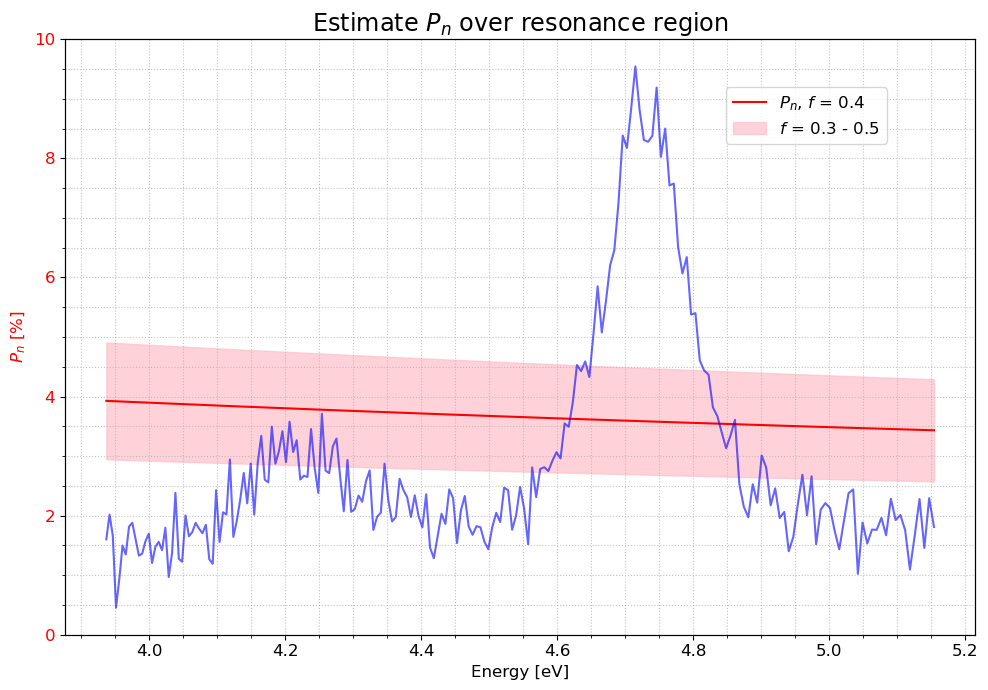

In [72]:
%matplotlib inline

# Sample data
r = 300
ch = 8
x = E_res_forPn
# y1 = voigt_D[r][ch]
y1 = fitted_curve
y2 = P_n_res
# ydata = bgsub_D[r][ch][bef_res_reg[1]-bef_res_reg[0]:aft_res_reg[0]-bef_res_reg[0]] 

f = 0.4
f_bot = 0.3
f_top = 0.5
P_n_res_bot = np.tanh(n*sigma_0*l*lamb_res_forPn*P_he*P_rb*f_bot)*100
P_n_res_top = np.tanh(n*sigma_0*l*lamb_res_forPn*P_he*P_rb*f_top)*100
y2 = P_n_res*100 ## in percent

# Create the main plot
fig, ax1 = plt.subplots()

# Plot the first dataset
ax1.plot(x, y2, color='red', label=f'$P_n$, $f$ = {f}')
ax1.set_ylabel(r'$P_n$ [%]', color='red', fontsize='large')
ax1.set_xlabel('Energy [eV]', fontsize='large')
ax1.tick_params(axis='x', labelsize = 'large')
ax1.tick_params(axis='y', labelcolor='red', labelsize = 'large')
plt.fill_between(x, P_n_res_bot, P_n_res_top, color='pink', alpha=0.7, label=f'$f$ = {f_bot} - {f_top}')
plt.ylim(0,10)

# Create a twin axes sharing the x-axis
ax2 = ax1.twinx()

## Plot the second dataset
# ax2.plot(x, test_bgsub_D_sum[ch][new_res_reg[0]:new_res_reg[1]]*1e-3, color ='blue',ls='none',marker='D',alpha = 0.6)
ax2.plot(x, ydata_forPn, color ='blue',alpha = 0.6)

# ax2.plot(x, y1, ls = '--', color='cyan', alpha = 0.6, label='Resonance fit')
# ax2.set_xlabel('Energy [eV]',fontsize = 'large')
# ax2.set_ylabel('counts [arbitrary]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_yticks([])

# ## Create a twin axes sharing the x-axis
# ax3 = ax1.twinx()

# ## Plot the second dataset
# ax3.plot(x, ydata, color='red', label='Dataset 3')
# ax2.plot(x, ydata)
# ax3.set_ylabel('Y-axis 2', color='red')
# ax3.tick_params(axis='y', labelcolor='red')

# Add legends
# fig.legend(loc="upper right", bbox_to_anchor=(0.1, 0.95))


# Display the plot

plt.title(r'Estimate $P_n$ over resonance region', fontsize = 'xx-large')

# plt.xticks(np.arange(-1.0,4.0, 0.5),fontsize = 'large')
ax1.grid(True, which='both',axis = 'both', alpha = 0.75, ls = ':')
ax1.minorticks_on()
# plt.xticks(fontsize = 'xx-large')
# plt.yticks(fontsize = 'x-small')
fig.legend(loc="upper right", bbox_to_anchor=(0.90, 0.88))

# plt.ylabel('NMR Signal Amplitude [mV]',fontsize = 'x-large')
# plt.xlabel('Energy [eV]',fontsize = 'x-large')

# plt.legend(fontsize = 'medium')
plt.show()

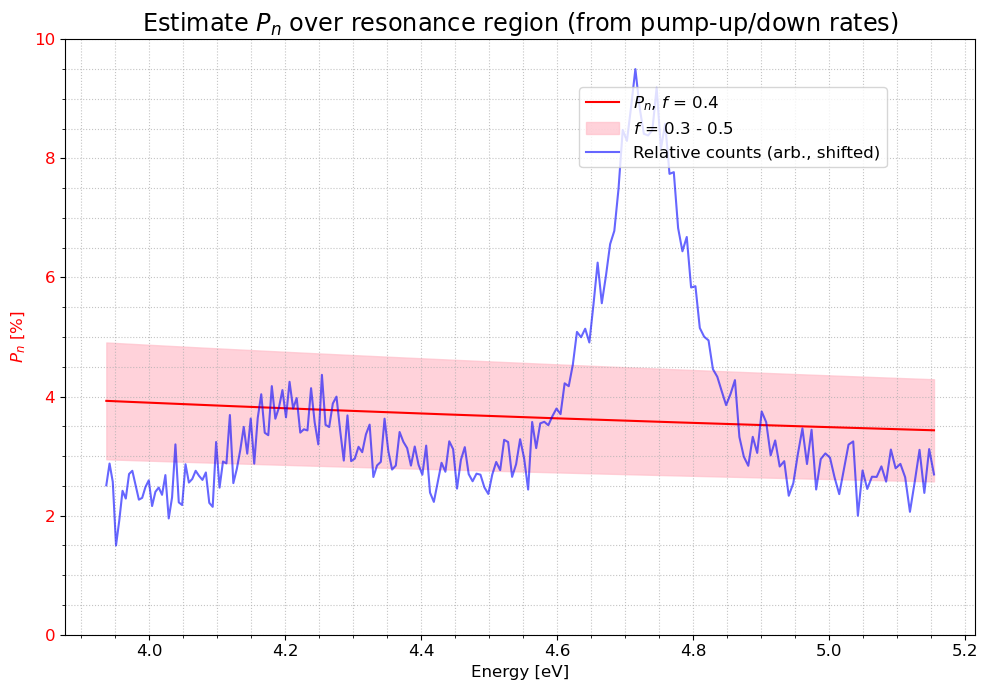

In [73]:
# Sample data
r = 300
ch = 8
x = E_res_forPn

y1 = fitted_curve
y2 = P_n_res * 100  # in percent

f = 0.4
f_bot = 0.3
f_top = 0.5

P_n_res_bot = np.tanh(n*sigma_0*l*lamb_res_forPn*P_he*P_rb*f_bot) * 100
P_n_res_top = np.tanh(n*sigma_0*l*lamb_res_forPn*P_he*P_rb*f_top) * 100

# ---- Normalize + shift blue curve (dimensionless visual guide) ----
y_blue = ydata_forPn
y_blue_scaled = (y_blue - np.min(y_blue)) / (np.max(y_blue) - np.min(y_blue))  # 0 → 1
y_blue_scaled = y_blue_scaled * 8.0   # adjust vertical size
y_blue_scaled = y_blue_scaled + 1.5   # shift downward (tune this)

# ---- Create plot ----
fig, ax1 = plt.subplots()

# Main physical curve
ax1.plot(x, y2, color='red', label=fr'$P_n$, $f$ = {f}')
ax1.set_ylabel(r'$P_n$ [%]', color='red', fontsize='large')
ax1.set_xlabel('Energy [eV]', fontsize='large')

ax1.tick_params(axis='x', labelsize='large')
ax1.tick_params(axis='y', labelcolor='red', labelsize='large')

# Uncertainty band
ax1.fill_between(
    x, P_n_res_bot, P_n_res_top,
    color='pink', alpha=0.7,
    label=fr'$f$ = {f_bot} - {f_top}'
)

# Blue guide curve (no units, just shape)
ax1.plot(
    x, y_blue_scaled,
    color='blue', alpha=0.6,
    label='Relative counts (arb., shifted)'
)

# Limits and styling
ax1.set_ylim(0, 10)
ax1.set_title(r'Estimate $P_n$ over resonance region (from pump-up/down rates)', fontsize='xx-large')

ax1.grid(True, which='both', axis='both', alpha=0.75, ls=':')
ax1.minorticks_on()

# Legend
fig.legend(loc="upper right", bbox_to_anchor=(0.90, 0.88))

plt.show()

#### now instead, use the value of Pn at E = 0.734 eV using the known La Asymm

In [74]:
my_msrmnts = [[6.94e-3, 7.2e-3], [1.02e-4, 1.04e-4]] # this should be for La


In [75]:
# values (excluding JINR)
A_lit = np.array([
    0.098,    # KEK(1)
    0.101,    # KEK(2)
    0.0936,   # KEK(3)
    0.092,    # LANL
    0.1015,   # Yuan (a)
    0.0955])    # Yuan (b)

sigma_lit = np.array([
    0.003,
    0.007,
    0.0016,
    0.017,
    0.0045,
    0.0035])

# weights
w = 1 / sigma_lit**2

# weighted average
A_avg_lit = np.sum(w * A_lit) / np.sum(w)

# uncertainty
A_err_lit = 1 / np.sqrt(np.sum(w))

print("Weighted average A =", A_avg_lit)
print("Uncertainty =", A_err_lit)

chi2 = np.sum(w * (A_lit - A_avg_lit)**2)
dof = len(A_lit) - 1

print("chi2 =", chi2)
print("chi2/dof =", chi2/dof)

Weighted average A = 0.09539647091159899
Uncertainty = 0.001234079095909907
chi2 = 4.535075123990343
chi2/dof = 0.9070150247980686


In [76]:
# my asym measurements for La
my_meas = np.array([6.94e-3, 7.2e-3])
my_meas_err = np.array([1.02e-4, 1.04e-4])

# literature (from previous weighted average)
A_phys = A_avg_lit
A_phys_err = A_err_lit

# compute Pn for each measurement
Pn = my_meas / A_phys

# propagate uncertainty
Pn_err = np.sqrt(
    (my_meas_err / A_phys)**2 +
    ((my_meas * A_phys_err) / A_phys**2)**2)

for i in range(len(Pn)):
    print(f"Measurement {i+1}: Pn = {Pn[i]:.4f} ± {Pn_err[i]:.4f}")

# weights
w = 1 / Pn_err**2

Pn_avg = np.sum(w * Pn) / np.sum(w)
Pn_avg_err = 1 / np.sqrt(np.sum(w))

print("Combined Pn =", Pn_avg)
print("Uncertainty =", Pn_avg_err)

Measurement 1: Pn = 0.0727 ± 0.0014
Measurement 2: Pn = 0.0755 ± 0.0015
Combined Pn = 0.07407487474392024
Uncertainty = 0.0010207410219338396


##### Now use the La results to back out the Pn at 4.24 eV

In [77]:
Pn_La = Pn_avg      # from previous calculation
Pn_La_err = Pn_avg_err

# wavelengths (Angstrom)
# print(tof_to_lambda(1.96, 23.31, 0.003))
# print(tof_to_lambda(tofres, fpl2, delay2))
lambda_La = tof_to_lambda(1.96, fpl2, delay2)      # ~0.7 eV
print(f'La p wave in Angstrom: {lambda_La}')
lambda_Pr = tof_to_lambda(tofres, fpl2, delay2)     # ~4.24 eV
print(f'Pr resonance in Angstrom: {lambda_Pr}')

# --- solve for Opacity ---
opacity = np.arctanh(Pn_La) / lambda_La

# --- predict Pn at Pr ---
Pn_Pr = np.tanh(opacity * lambda_Pr)

print("Derived Pn at 4.24 eV:", Pn_Pr)

La p wave in Angstrom: 0.3331484018864958
Pr resonance in Angstrom: 0.13926723310649947
Derived Pn at 4.24 eV: 0.031012664462214685


In [78]:
# # uncertainty
# def compute_Pn_Pr(Pn_La):
#     C = np.arctanh(Pn_La) / lambda_La
#     return np.tanh(C * lambda_Pr)

# # central value
# Pn_Pr = compute_Pn_Pr(Pn_La)

# # derivative (finite difference)
# dPn = 1e-6  ## just a small step size
# Pn_Pr_plus = compute_Pn_Pr(Pn_La + dPn)
# dPn_dPnLa = (Pn_Pr_plus - Pn_Pr) / dPn

# # propagate error
# Pn_Pr_err = abs(dPn_dPnLa) * Pn_La_err

# print("Pn_Pr =", Pn_Pr)
# print("Pn_Pr_err =", Pn_Pr_err)

In [79]:
# central value
Pn_Pr = np.tanh(np.arctanh(Pn_La) * (lambda_Pr / lambda_La))

# analytical derivative
dPn_dPnLa = (
    (1 - Pn_Pr**2) *
    (lambda_Pr / lambda_La) *
    (1 / (1 - Pn_La**2))
)

# propagated uncertainty
Pn_Pr_err = abs(dPn_dPnLa) * Pn_La_err

print("Pn_Pr =", Pn_Pr*100, '%')
print("Pn_Pr_err =", Pn_Pr_err*100, '%')

Pn_Pr = 3.101266446221469 %
Pn_Pr_err = 0.042864568500235435 %


In [66]:
print(lambda_La, lambda_Pr, Pn_La, Pn_Pr)
print(dPn_dPnLa, Pn_La_err)

0.3331484018864958 0.13926723310649947 0.07407487474392024 0.03101266446221469
0.41993578762051303 0.0010207410219338396


##### finally, get a bound on the Pr asymmetry using Pn from La

In [80]:
# my asymmetries for Pr
# A_meas_Pr = np.array([7.87e-3, 3.76e-3])
# A_meas_err_Pr = np.array([8.81e-3, 1.26e-2])
A_meas_Pr = np.array([8.056e-05, 9.752e-05])
A_meas_err_Pr = np.array([4.286e-04, 5.385e-04])

# weighted average
w = 1 / A_meas_err_Pr**2
A_avg_Pr = np.sum(w * A_meas_Pr) / np.sum(w)
A_err_Pr = 1 / np.sqrt(np.sum(w))

print("Measured asymmetry:")
print("A_avg_Pr =", A_avg_Pr*100, '%')
print("A_err_Pr =", A_err_Pr*100, '%')

Measured asymmetry:
A_avg_Pr = 0.008713725895198367 %
A_err_Pr = 0.033534763975422606 %


In [81]:
# physics asym
A_phys_Pr = A_avg_Pr / Pn_Pr

# propagate uncertainty
A_phys_err_Pr = np.sqrt(
    (A_err_Pr / Pn_Pr)**2 +
    (A_avg_Pr * Pn_Pr_err / Pn_Pr**2)**2)

print("\nPhysics asymmetry:")
print("A_phys =", A_phys_Pr*100, '%')
print("A_phys_err =", A_phys_err_Pr*100, '%')
print(f'Asymmetry < {(A_phys_Pr+2*A_phys_err_Pr)*100}% wirh 95% CL')


Physics asymmetry:
A_phys = 0.2809731458519156 %
A_phys_err = 1.0813317987584976 %
Asymmetry < 2.4436367433689106% wirh 95% CL


### now make a plot comparing my estimate model to the Pn found from La asym

In [94]:
%matplotlib qt
# ----------------------------
# 1. Convert TOF → energy + lambda
# ----------------------------
# E_res_forPn = tof_to_eV(xtof_forPn, fpl2, delay2)
# lamb_res_forPn = tof_to_lambda_direct(xtof_forPn, fpl2, delay2)

# La reference point
lambda_La = tof_to_lambda(1.96, fpl2, delay2)

# ----------------------------
# 2. MODEL P_n (original)
# ----------------------------
P_n_model = np.tanh(n * sigma_0 * l * lamb_res_forPn * P_he * P_rb * f)

# --- model band ---
f_bot = 0.3
f_top = 0.5

P_n_model_bot = np.tanh(n * sigma_0 * l * lamb_res_forPn * P_he * P_rb * f_bot)
P_n_model_top = np.tanh(n * sigma_0 * l * lamb_res_forPn * P_he * P_rb * f_top)

# ----------------------------
# 3. DATA-CALIBRATED P_n
# ----------------------------
C_data = np.arctanh(Pn_avg) / lambda_La
P_n_cal = np.tanh(C_data * lamb_res_forPn)

# ----------------------------
# 4. BLUE RESONANCE SHAPE (from cell2)
# ----------------------------
y_blue = ydata_forPn

# normalize to 0–1
y_blue_scaled = (y_blue - np.min(y_blue)) / (np.max(y_blue) - np.min(y_blue))

# scale + shift (tune if needed)
y_blue_scaled = y_blue_scaled * 8.0
y_blue_scaled = y_blue_scaled + 1.0

# ----------------------------
# 5. PLOT
# ----------------------------
fig, ax = plt.subplots()

# Model curve
ax.plot(E_res_forPn, P_n_model * 100,
        color='red', label='Estimate $P_n$ from pump-up/down times')

# Model band
ax.fill_between(
    E_res_forPn,
    P_n_model_bot * 100,
    P_n_model_top * 100,
    color='pink', alpha=0.6,
    label=fr'Estimate band ($f$={f_bot}-{f_top})'
)

# Calibrated curve
ax.plot(E_res_forPn, P_n_cal * 100,
        color='black', ls='--',
        label='$P_n$ derived from La asymmetry')

# Blue resonance shape (unitless)
ax.plot(
    E_res_forPn, y_blue_scaled,
    color='blue', alpha=0.6,
    label='Resonance region (arb., illustrative only)'
)

# ----------------------------
# 6. FORMATTING
# ----------------------------
ax.set_xlabel('Energy [eV]')
ax.set_ylabel('$P_n$ [%]', color = 'red')
ax.tick_params(axis='y', labelcolor='red', labelsize='large')
ax.set_title('Neutron Polarization in Pr Resonance Region')
ax.grid(True, alpha=0.75, ls=':')
ax.minorticks_on()
ax.set_ylim(bottom=0, top=8)

ax.legend()

plt.show()

In [82]:
print(lamb_res_forPn.shape)
print(C_hi, C_lo)

(210,)
[0.22705563 0.22717362] [0.2184573  0.21833935]


### testing area

In [ ]:
plt.plot(x_rebin,y_rebin)